# 02 — Deteksi, Screening Regional, dan Visualisasi Flash Drought Indonesia (Revisi Final)

Notebook ini membaca keluaran Notebook 01:

- `rzsm_percentile_gringorten_1995_2025.nc`
- `rzsm_pentad_1995_2025.nc`

dan menghasilkan deteksi grid-cell, katalog kejadian, screening luas wilayah, peringkat tahun kandidat, serta figur quality control.

## Definisi operasional primer

1. **Baseline** adalah pentad terakhir dengan RZSM percentile ≥P40 sebelum nilai turun ke bawah P40.
2. Nilai mencapai **<P20** selama fase onset.
3. Laju onset dihitung **satu kali setelah crossing P20 ditemukan**:

\[
v = \frac{P_{\mathrm{baseline}}-P_{\mathrm{crossing}}}
{t_{\mathrm{crossing}}-t_{\mathrm{baseline}}}
\]

   dan harus ≥5 percentile points per pentad.
4. Secara default, setiap langkah antara baseline dan crossing harus menurun (`STRICT_MONOTONIC=True`).
5. Terminasi adalah pentad pertama ketika RZSM kembali ≥P20.
6. Durasi total minimum adalah empat interval pentad atau 20 hari.
7. Kejadian yang belum pulih pada akhir data (*right-censored*) tidak dimasukkan.

## Kode fase

- `0`: tidak ada kejadian aktif;
- `1`: rapid-onset stage, baseline sampai crossing pertama <P20;
- `2`: post-crossing intensification/persistence, setelah crossing sampai minimum;
- `3`: recovery stage, setelah minimum sampai sebelum terminasi.

Kejadian panjang tidak otomatis dibuang. Kejadian dengan durasi melebihi
`LONG_EVENT_PENTADS` diberi kelas **flash-onset prolonged drought**. Parameter batas
onset, persistence di bawah P20, dan durasi maksimum disediakan untuk sensitivity analysis,
tetapi tidak diaktifkan pada definisi primer.


## 0. Paket

Hapus tanda `#` pada baris instalasi hanya apabila paket belum tersedia.


In [1]:
# %pip install numpy pandas xarray dask netCDF4 h5netcdf h5py bottleneck numba scipy matplotlib pyarrow
# Mask Indonesia otomatis atau dari file lokal:
# %pip install geopandas regionmask shapely


## 1. Impor


In [2]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy import ndimage
from numba import njit
from IPython.display import display

try:
    from dask.diagnostics import ProgressBar
except Exception:
    ProgressBar = None

warnings.filterwarnings("once")

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Xarray:", xr.__version__)


NumPy : 2.4.6
Pandas: 3.0.3
Xarray: 2026.7.0


## 2. Konfigurasi

Bagian yang paling mungkin perlu diubah hanya `INPUT_DIR`, `OUTPUT_DIR`, dan—bila tersedia—
`INDONESIA_BOUNDARY_FILE`.


In [3]:
INPUT_DIR = Path(r"D:\ERA5_LAND\output_rzsm")
OUTPUT_DIR = Path(r"D:\ERA5_LAND\output_fd_q1_revisi_final")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PERCENTILE_FILE = INPUT_DIR / "rzsm_percentile_gringorten_1995_2025.nc"
RZSM_FILE = INPUT_DIR / "rzsm_pentad_1995_2025.nc"

# Definisi primer
START_THRESHOLD = 40.0
DROUGHT_THRESHOLD = 20.0
MIN_DECLINE_RATE = 5.0
MIN_TOTAL_DURATION = 4
STRICT_MONOTONIC = True

# Parameter sensitivity analysis. None berarti tidak diterapkan.
MAX_ONSET_PENTADS = None
MIN_BELOW_P20_PENTADS = 1
MAX_TOTAL_DURATION = None

# Hanya untuk klasifikasi, bukan filter.
LONG_EVENT_PENTADS = 18

# Notebook 01 menggunakan 31 tahun (1995–2025).
MIN_VALID_YEARS = 31

LAT_CHUNK = 15
LON_CHUNK = 40
TIME_CHUNK_OUTPUT = 73

# Gunakan satu file polygon Indonesia apabila tersedia.
# Format dapat berupa .shp, .gpkg, atau .geojson.
INDONESIA_BOUNDARY_FILE = None
TRY_BUILTIN_NATURAL_EARTH = True
REQUIRE_INDONESIA_MASK = False

CALCULATE_LARGEST_CLUSTER = True
REGIONAL_AREA_THRESHOLDS = [1.0, 5.0, 10.0]

# Tahun dan titik dapat diisi manual. None = dipilih otomatis.
SELECTED_YEAR = None
SELECTED_LAT = None
SELECTED_LON = None

# Kriteria eksplisit untuk memilih tahun dan pentad contoh.
YEAR_SELECTION_METRIC = "maximum_drought_core_area_percent"
PEAK_SELECTION_METRIC = "drought_core_area_percent"

FIGURE_DPI = 600
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True
OVERWRITE = True

try:
    import h5netcdf  # noqa: F401
    NETCDF_ENGINE = "h5netcdf"
except Exception:
    NETCDF_ENGINE = "netcdf4"

MAX_ONSET_PENTADS_INT = -1 if MAX_ONSET_PENTADS is None else int(MAX_ONSET_PENTADS)
MAX_TOTAL_DURATION_INT = -1 if MAX_TOTAL_DURATION is None else int(MAX_TOTAL_DURATION)

print("Backend NetCDF:", NETCDF_ENGINE)


Backend NetCDF: h5netcdf


## 3. Gaya figur dan fungsi penyimpanan


In [4]:
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.titlesize": 11,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.4,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def save_figure(fig, stem):
    stem = OUTPUT_DIR / stem
    if SAVE_PNG:
        fig.savefig(stem.with_suffix(".png"), dpi=FIGURE_DPI, bbox_inches="tight")
    if SAVE_PDF:
        fig.savefig(stem.with_suffix(".pdf"), bbox_inches="tight")
    if SAVE_SVG:
        fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
    print("Figur tersimpan:", stem)


## 4. Baca dan validasi keluaran Notebook 01


In [5]:
for file_path in [PERCENTILE_FILE, RZSM_FILE]:
    if not file_path.exists():
        raise FileNotFoundError(
            f"File tidak ditemukan: {file_path}\n"
            "Periksa INPUT_DIR dan nama keluaran Notebook 01."
        )

ds_pct = xr.open_dataset(
    PERCENTILE_FILE,
    chunks={
        "year": -1,
        "pentad": -1,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
)
ds_rzsm = xr.open_dataset(
    RZSM_FILE,
    chunks={
        "year": -1,
        "pentad": -1,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
)

if "rzsm_percentile" not in ds_pct:
    raise KeyError(
        f"'rzsm_percentile' tidak ada. Variabel tersedia: {list(ds_pct.data_vars)}"
    )
if "rzsm" not in ds_rzsm:
    raise KeyError(f"'rzsm' tidak ada. Variabel tersedia: {list(ds_rzsm.data_vars)}")

rzsm_percentile, rzsm_pentad = xr.align(
    ds_pct["rzsm_percentile"],
    ds_rzsm["rzsm"],
    join="exact",
)

required_dims = {"year", "pentad", "latitude", "longitude"}
for name, da in {
    "rzsm_percentile": rzsm_percentile,
    "rzsm": rzsm_pentad,
}.items():
    missing = required_dims - set(da.dims)
    if missing:
        raise ValueError(f"{name} kehilangan dimensi: {sorted(missing)}")

expected_years = np.arange(1995, 2026)
expected_pentads = np.arange(1, 74)

if not np.array_equal(rzsm_percentile["year"].values, expected_years):
    raise ValueError(
        "Koordinat year tidak persis 1995–2025. "
        f"Ditemukan: {rzsm_percentile['year'].values}"
    )
if not np.array_equal(rzsm_percentile["pentad"].values, expected_pentads):
    raise ValueError(
        "Koordinat pentad tidak persis 1–73. "
        f"Ditemukan: {rzsm_percentile['pentad'].values}"
    )

print(rzsm_percentile)


<frozen importlib._bootstrap>:488: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


<xarray.DataArray 'rzsm_percentile' (year: 31, pentad: 73, latitude: 171,
                                     longitude: 461)> Size: 714MB
dask.array<open_dataset-rzsm_percentile, shape=(31, 73, 171, 461), dtype=float32, chunksize=(31, 73, 15, 40), chunktype=numpy.ndarray>
Coordinates:
  * year              (year) int64 248B 1995 1996 1997 1998 ... 2023 2024 2025
  * pentad            (pentad) int16 146B 1 2 3 4 5 6 7 ... 67 68 69 70 71 72 73
    pentad_start_doy  (pentad) int16 146B dask.array<chunksize=(73,), meta=np.ndarray>
    pentad_end_doy    (pentad) int16 146B dask.array<chunksize=(73,), meta=np.ndarray>
  * latitude          (latitude) float64 1kB -11.0 -10.9 -10.8 ... 5.8 5.9 6.0
  * longitude         (longitude) float64 4kB 95.0 95.1 95.2 ... 140.9 141.0
    number            int64 8B ...
Attributes: (12/38)
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      78831
    GRIB_typeOfLevel:                         depthBelowLandLayer


C:\Users\User\AppData\Local\Temp\ipykernel_2448\224265462.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 15. This could degrade performance. Instead, consider rechunking after loading.
  ds_pct = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_2448\224265462.py:8: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting at index 40. This could degrade performance. Instead, consider rechunking after loading.
  ds_pct = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_2448\224265462.py:17: UserWarning: The specified chunks separate the stored chunks along dimension "latitude" starting at index 15. This could degrade performance. Instead, consider rechunking after loading.
  ds_rzsm = xr.open_dataset(
C:\Users\User\AppData\Local\Temp\ipykernel_2448\224265462.py:17: UserWarning: The specified chunks separate the stored chunks along dimension "longitude" starting 

## 5. Bentuk sumbu waktu kontinu


In [6]:
pct_stacked = rzsm_percentile.stack(time_index=("year", "pentad"))
rzsm_stacked = rzsm_pentad.stack(time_index=("year", "pentad"))

year_of_step = pct_stacked["year"].values.astype(np.int16)
pentad_of_step = pct_stacked["pentad"].values.astype(np.int16)
ntime = pct_stacked.sizes["time_index"]
simple_time_index = np.arange(ntime, dtype=np.int32)

def remove_multiindex_and_standardize(da):
    return (
        da.reset_index("time_index", drop=True)
        .assign_coords(
            time_index=("time_index", simple_time_index),
            year=("time_index", year_of_step),
            pentad=("time_index", pentad_of_step),
        )
        .transpose("latitude", "longitude", "time_index")
        .chunk({
            "latitude": LAT_CHUNK,
            "longitude": LON_CHUNK,
            "time_index": -1,
        })
    )

pct_time = remove_multiindex_and_standardize(pct_stacked)
rzsm_time = remove_multiindex_and_standardize(rzsm_stacked)

print("Jumlah langkah:", ntime)
print("Awal:", int(year_of_step[0]), int(pentad_of_step[0]))
print("Akhir:", int(year_of_step[-1]), int(pentad_of_step[-1]))


Jumlah langkah: 2263
Awal: 1995 1
Akhir: 2025 73


## 6. Mask grid valid dan polygon Indonesia

Urutan mask:

1. validitas klimatologi dari `n_valid_years`;
2. polygon lokal bila disediakan;
3. bila tidak tersedia, notebook mencoba Natural Earth bawaan `regionmask`;
4. bila keduanya gagal, notebook hanya memakai bounding box dan memberi label
   `bbox_screening` agar hasil tidak keliru disebut statistik Indonesia final.


In [7]:
if "n_valid_years" in ds_pct:
    nvalid = ds_pct["n_valid_years"]
    reduce_dims = [
        dim for dim in nvalid.dims
        if dim not in {"latitude", "longitude"}
    ]
    if reduce_dims:
        valid_grid = nvalid.min(reduce_dims) >= MIN_VALID_YEARS
    else:
        valid_grid = nvalid >= MIN_VALID_YEARS
else:
    valid_grid = rzsm_percentile.notnull().all(("year", "pentad"))

valid_grid = valid_grid.transpose("latitude", "longitude")
polygon_mask = None
mask_source = None
mask_is_indonesia = False

def polygon_mask_from_local_file(path):
    import geopandas as gpd
    import regionmask

    boundary = gpd.read_file(path).to_crs("EPSG:4326")
    boundary = boundary.loc[
        boundary.geometry.notnull() & ~boundary.geometry.is_empty
    ].copy()
    if boundary.empty:
        raise ValueError("File batas tidak memiliki geometri valid.")

    if hasattr(boundary.geometry, "union_all"):
        geometry = boundary.geometry.union_all()
    else:
        geometry = boundary.geometry.unary_union

    regions = regionmask.Regions(
        outlines=[geometry],
        names=["Indonesia"],
        abbrevs=["IDN"],
        numbers=[1],
    )
    return regions.mask(
        rzsm_percentile["longitude"],
        rzsm_percentile["latitude"],
    ).notnull()

def polygon_mask_from_builtin_natural_earth():
    import regionmask

    versions = [
        "natural_earth_v5_1_2",
        "natural_earth_v5_0_0",
        "natural_earth_v4_1_0",
    ]
    resolutions = ["countries_50", "countries_110"]

    errors = []
    for version_name in versions:
        version = getattr(regionmask.defined_regions, version_name, None)
        if version is None:
            continue
        for resolution_name in resolutions:
            countries = getattr(version, resolution_name, None)
            if countries is None:
                continue
            try:
                names = [str(name) for name in countries.names]
                matches = [
                    i for i, name in enumerate(names)
                    if name.strip().lower() == "indonesia"
                ]
                if not matches:
                    continue
                position = matches[0]
                region_number = int(countries.numbers[position])
                country_codes = countries.mask(
                    rzsm_percentile["longitude"],
                    rzsm_percentile["latitude"],
                )
                return country_codes == region_number, (
                    f"regionmask {version_name}.{resolution_name}"
                )
            except Exception as exc:
                errors.append(
                    f"{version_name}.{resolution_name}: {type(exc).__name__}: {exc}"
                )

    raise RuntimeError(
        "Natural Earth Indonesia tidak dapat dibaca. "
        + (" | ".join(errors) if errors else "Tidak ada koleksi yang cocok.")
    )

if INDONESIA_BOUNDARY_FILE is not None:
    boundary_path = Path(INDONESIA_BOUNDARY_FILE)
    if not boundary_path.exists():
        raise FileNotFoundError(f"Polygon Indonesia tidak ditemukan: {boundary_path}")
    polygon_mask = polygon_mask_from_local_file(boundary_path)
    mask_source = str(boundary_path)
    mask_is_indonesia = True

elif TRY_BUILTIN_NATURAL_EARTH:
    try:
        polygon_mask, mask_source = polygon_mask_from_builtin_natural_earth()
        mask_is_indonesia = True
        print("Mask Indonesia otomatis:", mask_source)
    except Exception as exc:
        print("Mask Natural Earth tidak tersedia:", exc)

if polygon_mask is not None:
    valid_grid = valid_grid & polygon_mask
    mask_description = (
        "valid ERA5-Land grids inside the Indonesia polygon"
    )
    domain_tag = "indonesia"
else:
    mask_description = (
        "valid ERA5-Land land grids inside the Notebook 01 bounding box; "
        "not an Indonesia administrative mask"
    )
    domain_tag = "bbox_screening"
    message = (
        "PERINGATAN: polygon Indonesia belum diterapkan. "
        "Output diberi tag 'bbox_screening' dan tidak boleh ditafsirkan "
        "sebagai statistik Indonesia final."
    )
    if REQUIRE_INDONESIA_MASK:
        raise RuntimeError(message)
    print(message)

valid_grid = valid_grid.compute()
if int(valid_grid.sum()) == 0:
    raise ValueError("Mask menghasilkan nol grid valid.")

pct_time = pct_time.where(valid_grid)
rzsm_time = rzsm_time.where(valid_grid)

DETECTION_FILE = OUTPUT_DIR / f"fd_detection_primary_1995_2025_{domain_tag}.nc"
CATALOG_FILE = OUTPUT_DIR / f"fd_gridcell_event_catalog_1995_2025_{domain_tag}.csv"
SCREENING_FILE = OUTPUT_DIR / f"fd_annual_regional_screening_1995_2025_{domain_tag}.csv"
PENTAD_SCREENING_FILE = OUTPUT_DIR / f"fd_pentad_area_screening_1995_2025_{domain_tag}.csv"
MANIFEST_FILE = OUTPUT_DIR / f"fd_run_manifest_1995_2025_{domain_tag}.json"

print("Mask:", mask_description)
print("Sumber mask:", mask_source)
print("Grid valid:", f"{int(valid_grid.sum()):,}")
print("Domain tag:", domain_tag)


Mask Natural Earth tidak tersedia: No module named 'regionmask'
PERINGATAN: polygon Indonesia belum diterapkan. Output diberi tag 'bbox_screening' dan tidak boleh ditafsirkan sebagai statistik Indonesia final.
Mask: valid ERA5-Land land grids inside the Notebook 01 bounding box; not an Indonesia administrative mask
Sumber mask: None
Grid valid: 18,076
Domain tag: bbox_screening


## 7. Fungsi deteksi

Perbaikan utama: `mean_decline` tidak lagi diperiksa pada setiap pentad.
Crossing <P20 dicari terlebih dahulu, lalu laju rata-rata baseline–crossing dihitung sekali.


In [8]:
@njit
def detect_one_series(
    p,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    max_total_duration,
    long_event_pentads,
):
    n = p.size

    phase = np.zeros(n, dtype=np.int8)
    event_id = np.zeros(n, dtype=np.int16)
    event_start = np.zeros(n, dtype=np.int8)
    threshold_crossing = np.zeros(n, dtype=np.int8)
    minimum_flag = np.zeros(n, dtype=np.int8)
    event_termination = np.zeros(n, dtype=np.int8)
    drought_core = np.zeros(n, dtype=np.int8)

    duration = np.full(n, -1, dtype=np.int16)
    onset_time = np.full(n, -1, dtype=np.int16)
    below_p20_duration = np.full(n, -1, dtype=np.int16)
    post_crossing_to_minimum = np.full(n, -1, dtype=np.int16)
    recovery_time = np.full(n, -1, dtype=np.int16)

    onset_speed = np.full(n, np.nan, dtype=np.float32)
    severity40 = np.full(n, np.nan, dtype=np.float32)
    severity20 = np.full(n, np.nan, dtype=np.float32)
    minimum_percentile = np.full(n, np.nan, dtype=np.float32)

    crossing_index_at_start = np.full(n, -1, dtype=np.int32)
    minimum_index_at_start = np.full(n, -1, dtype=np.int32)
    termination_index_at_start = np.full(n, -1, dtype=np.int32)
    event_class_at_start = np.zeros(n, dtype=np.int8)

    local_event_id = 0
    i = 0

    while i < n - 1:
        if np.isnan(p[i]) or np.isnan(p[i + 1]):
            i += 1
            continue

        # Baseline terakhir >=P40 sebelum seri turun ke bawah P40.
        if not (
            p[i] >= start_threshold
            and p[i + 1] < start_threshold
        ):
            i += 1
            continue

        baseline = i
        crossing = -1
        j = baseline + 1

        # Cari crossing <P20. Jangan menguji mean decline di setiap langkah.
        while j < n:
            if np.isnan(p[j]) or np.isnan(p[j - 1]):
                break

            if (
                max_onset_pentads > 0
                and (j - baseline) > max_onset_pentads
            ):
                break

            if strict_monotonic and not (p[j] < p[j - 1]):
                break

            if p[j] < drought_threshold:
                crossing = j
                break

            j += 1

        if crossing < 0:
            i += 1
            continue

        current_onset_time = crossing - baseline
        current_onset_speed = (
            p[baseline] - p[crossing]
        ) / current_onset_time

        if current_onset_speed < min_decline_rate:
            i += 1
            continue

        # Terminasi pertama ketika nilai kembali >=P20.
        termination = -1
        missing_during_event = False
        k = crossing + 1

        while k < n:
            if np.isnan(p[k]):
                missing_during_event = True
                break
            if p[k] >= drought_threshold:
                termination = k
                break
            k += 1

        # Missing data di tengah kandidat tidak boleh menghentikan seluruh seri.
        if missing_during_event:
            i = k + 1
            continue

        # Kandidat yang belum pulih pada ujung seri adalah right-censored.
        if termination < 0:
            break

        total_duration = termination - baseline
        current_below_p20_duration = termination - crossing

        if total_duration < min_total_duration:
            i = termination
            continue

        if current_below_p20_duration < min_below_p20_pentads:
            i = termination
            continue

        if (
            max_total_duration > 0
            and total_duration > max_total_duration
        ):
            i = termination
            continue

        min_value = p[crossing]
        min_index = crossing
        sev40 = 0.0
        sev20 = 0.0

        for q in range(baseline + 1, termination):
            if p[q] < min_value:
                min_value = p[q]
                min_index = q
            if p[q] < start_threshold:
                sev40 += start_threshold - p[q]
            if p[q] < drought_threshold:
                sev20 += drought_threshold - p[q]

        local_event_id += 1

        event_start[baseline] = 1
        threshold_crossing[crossing] = 1
        minimum_flag[min_index] = 1
        event_termination[termination] = 1

        duration[baseline] = total_duration
        onset_time[baseline] = current_onset_time
        below_p20_duration[baseline] = current_below_p20_duration
        post_crossing_to_minimum[baseline] = min_index - crossing
        recovery_time[baseline] = termination - min_index

        onset_speed[baseline] = current_onset_speed
        severity40[baseline] = sev40
        severity20[baseline] = sev20
        minimum_percentile[baseline] = min_value

        crossing_index_at_start[baseline] = crossing
        minimum_index_at_start[baseline] = min_index
        termination_index_at_start[baseline] = termination

        if (
            long_event_pentads > 0
            and total_duration > long_event_pentads
        ):
            event_class_at_start[baseline] = 2
        else:
            event_class_at_start[baseline] = 1

        for q in range(baseline, termination):
            event_id[q] = local_event_id

        # 1 = rapid onset, baseline sampai crossing.
        for q in range(baseline, crossing + 1):
            phase[q] = 1

        # 2 = setelah crossing sampai minimum.
        for q in range(crossing + 1, min_index + 1):
            phase[q] = 2

        # 3 = setelah minimum sampai sebelum terminasi.
        for q in range(min_index + 1, termination):
            phase[q] = 3

        for q in range(crossing, termination):
            if p[q] < drought_threshold:
                drought_core[q] = 1

        i = termination

    return (
        phase,
        event_id,
        event_start,
        threshold_crossing,
        minimum_flag,
        event_termination,
        drought_core,
        duration,
        onset_time,
        below_p20_duration,
        post_crossing_to_minimum,
        recovery_time,
        onset_speed,
        severity40,
        severity20,
        minimum_percentile,
        crossing_index_at_start,
        minimum_index_at_start,
        termination_index_at_start,
        event_class_at_start,
    )


@njit
def detect_block(
    p_block,
    start_threshold,
    drought_threshold,
    min_decline_rate,
    min_total_duration,
    strict_monotonic,
    max_onset_pentads,
    min_below_p20_pentads,
    max_total_duration,
    long_event_pentads,
):
    original_shape = p_block.shape
    nt = original_shape[-1]
    npixel = p_block.size // nt
    flat = p_block.reshape((npixel, nt))

    phase = np.zeros((npixel, nt), dtype=np.int8)
    event_id = np.zeros((npixel, nt), dtype=np.int16)
    event_start = np.zeros((npixel, nt), dtype=np.int8)
    threshold_crossing = np.zeros((npixel, nt), dtype=np.int8)
    minimum_flag = np.zeros((npixel, nt), dtype=np.int8)
    event_termination = np.zeros((npixel, nt), dtype=np.int8)
    drought_core = np.zeros((npixel, nt), dtype=np.int8)

    duration = np.full((npixel, nt), -1, dtype=np.int16)
    onset_time = np.full((npixel, nt), -1, dtype=np.int16)
    below_p20_duration = np.full((npixel, nt), -1, dtype=np.int16)
    post_crossing_to_minimum = np.full((npixel, nt), -1, dtype=np.int16)
    recovery_time = np.full((npixel, nt), -1, dtype=np.int16)

    onset_speed = np.full((npixel, nt), np.nan, dtype=np.float32)
    severity40 = np.full((npixel, nt), np.nan, dtype=np.float32)
    severity20 = np.full((npixel, nt), np.nan, dtype=np.float32)
    minimum_percentile = np.full((npixel, nt), np.nan, dtype=np.float32)

    crossing_index_at_start = np.full((npixel, nt), -1, dtype=np.int32)
    minimum_index_at_start = np.full((npixel, nt), -1, dtype=np.int32)
    termination_index_at_start = np.full((npixel, nt), -1, dtype=np.int32)
    event_class_at_start = np.zeros((npixel, nt), dtype=np.int8)

    for pixel in range(npixel):
        r = detect_one_series(
            flat[pixel],
            start_threshold,
            drought_threshold,
            min_decline_rate,
            min_total_duration,
            strict_monotonic,
            max_onset_pentads,
            min_below_p20_pentads,
            max_total_duration,
            long_event_pentads,
        )

        phase[pixel] = r[0]
        event_id[pixel] = r[1]
        event_start[pixel] = r[2]
        threshold_crossing[pixel] = r[3]
        minimum_flag[pixel] = r[4]
        event_termination[pixel] = r[5]
        drought_core[pixel] = r[6]

        duration[pixel] = r[7]
        onset_time[pixel] = r[8]
        below_p20_duration[pixel] = r[9]
        post_crossing_to_minimum[pixel] = r[10]
        recovery_time[pixel] = r[11]

        onset_speed[pixel] = r[12]
        severity40[pixel] = r[13]
        severity20[pixel] = r[14]
        minimum_percentile[pixel] = r[15]

        crossing_index_at_start[pixel] = r[16]
        minimum_index_at_start[pixel] = r[17]
        termination_index_at_start[pixel] = r[18]
        event_class_at_start[pixel] = r[19]

    return (
        phase.reshape(original_shape),
        event_id.reshape(original_shape),
        event_start.reshape(original_shape),
        threshold_crossing.reshape(original_shape),
        minimum_flag.reshape(original_shape),
        event_termination.reshape(original_shape),
        drought_core.reshape(original_shape),
        duration.reshape(original_shape),
        onset_time.reshape(original_shape),
        below_p20_duration.reshape(original_shape),
        post_crossing_to_minimum.reshape(original_shape),
        recovery_time.reshape(original_shape),
        onset_speed.reshape(original_shape),
        severity40.reshape(original_shape),
        severity20.reshape(original_shape),
        minimum_percentile.reshape(original_shape),
        crossing_index_at_start.reshape(original_shape),
        minimum_index_at_start.reshape(original_shape),
        termination_index_at_start.reshape(original_shape),
        event_class_at_start.reshape(original_shape),
    )


## 8. Unit tests sintetis


Semua unit tests lulus.


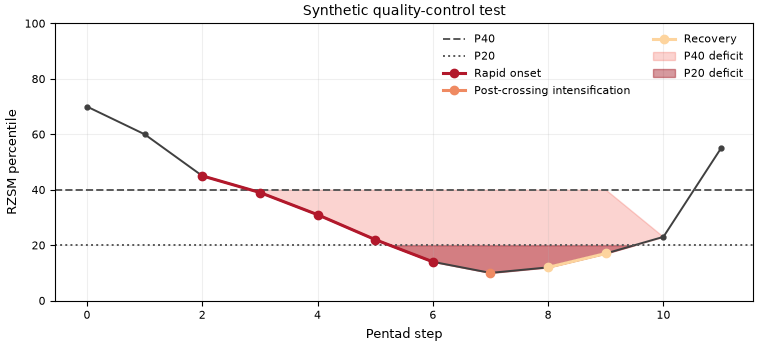

In [9]:
def run_synthetic(
    values,
    strict_monotonic=STRICT_MONOTONIC,
    max_onset_pentads=MAX_ONSET_PENTADS_INT,
    min_below_p20_pentads=MIN_BELOW_P20_PENTADS,
    max_total_duration=MAX_TOTAL_DURATION_INT,
    min_total_duration=MIN_TOTAL_DURATION,
):
    return detect_one_series(
        np.asarray(values, dtype=np.float64),
        START_THRESHOLD,
        DROUGHT_THRESHOLD,
        MIN_DECLINE_RATE,
        min_total_duration,
        strict_monotonic,
        max_onset_pentads,
        min_below_p20_pentads,
        max_total_duration,
        LONG_EVENT_PENTADS,
    )

# A. Kejadian valid dengan indeks yang diketahui.
synthetic_main = [
    70, 60, 45, 39, 31, 22, 14, 10, 12, 17, 23, 55
]
test_main = run_synthetic(synthetic_main)
baseline = int(np.flatnonzero(test_main[2] == 1)[0])

assert baseline == 2
assert int(test_main[16][baseline]) == 6
assert int(test_main[17][baseline]) == 7
assert int(test_main[18][baseline]) == 10
assert int(test_main[7][baseline]) == 8
assert int(test_main[8][baseline]) == 4
assert np.isclose(float(test_main[12][baseline]), 7.75)
assert int(test_main[9][baseline]) == 4
assert set(np.unique(test_main[0])).issubset({0, 1, 2, 3})

# B. Kasus yang dahulu keliru ditolak:
# 42 -> 39 hanya turun 3 pp pada langkah pertama, tetapi
# laju baseline-crossing = (42-15)/2 = 13.5 pp/pentad.
test_cumulative = run_synthetic([42, 39, 15, 14, 25])
assert int(test_cumulative[2].sum()) == 1
assert np.isclose(float(test_cumulative[12][0]), 13.5)

# C. Non-monotonik ditolak saat strict=True dan diterima saat strict=False.
test_nonmonotonic_strict = run_synthetic(
    [45, 35, 37, 15, 10, 25],
    strict_monotonic=True,
)
test_nonmonotonic_loose = run_synthetic(
    [45, 35, 37, 15, 10, 25],
    strict_monotonic=False,
)
assert int(test_nonmonotonic_strict[2].sum()) == 0
assert int(test_nonmonotonic_loose[2].sum()) == 1

# D. P20 tepat belum termasuk crossing; crossing harus <P20.
test_exact_p20 = run_synthetic([45, 35, 20, 19, 18, 25])
assert int(np.flatnonzero(test_exact_p20[3] == 1)[0]) == 3

# E. Missing data di kandidat dan right-censored tidak diterima.
assert int(run_synthetic([45, 35, np.nan, 15, 10, 25])[2].sum()) == 0
assert int(run_synthetic([45, 35, 25, 15, 10])[2].sum()) == 0

# F. Filter persistence dapat diaktifkan tanpa mengubah fungsi.
test_persistence = run_synthetic(
    [45, 30, 15, 25],
    min_total_duration=3,
    min_below_p20_pentads=2,
)
assert int(test_persistence[2].sum()) == 0

print("Semua unit tests lulus.")

x_test = np.arange(len(synthetic_main))
p_test = np.asarray(synthetic_main, dtype=float)
phase_test = test_main[0]

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(x_test, p_test, marker="o", markersize=3.5, color="0.25")
ax.axhline(START_THRESHOLD, linestyle="--", color="0.35", label="P40")
ax.axhline(DROUGHT_THRESHOLD, linestyle=":", color="0.35", label="P20")

for phase_code, label, color in [
    (1, "Rapid onset", "#b2182b"),
    (2, "Post-crossing intensification", "#ef8a62"),
    (3, "Recovery", "#fdd49e"),
]:
    mask = phase_test == phase_code
    if mask.any():
        ax.plot(
            x_test[mask],
            p_test[mask],
            marker="o",
            linewidth=2.2,
            color=color,
            label=label,
        )

ax.fill_between(
    x_test,
    p_test,
    START_THRESHOLD,
    where=(phase_test > 0) & (p_test < START_THRESHOLD),
    interpolate=True,
    color="#ef3b2c",
    alpha=0.22,
    label="P40 deficit",
)
ax.fill_between(
    x_test,
    p_test,
    DROUGHT_THRESHOLD,
    where=test_main[6] == 1,
    interpolate=True,
    color="#99000d",
    alpha=0.40,
    label="P20 deficit",
)

ax.set(
    xlabel="Pentad step",
    ylabel="RZSM percentile",
    title="Synthetic quality-control test",
    ylim=(0, 100),
)
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)
plt.show()


## 9. Deteksi seluruh grid


In [10]:
output_names = [
    "fd_phase",
    "fd_event_id",
    "fd_event_start",
    "fd_threshold_crossing",
    "fd_minimum_flag",
    "fd_event_termination",
    "fd_drought_core",
    "duration_pentads_at_start",
    "onset_time_pentads_at_start",
    "below_p20_pentads_at_start",
    "post_crossing_to_minimum_pentads_at_start",
    "recovery_time_pentads_at_start",
    "onset_speed_at_start",
    "severity_p40_at_start",
    "severity_p20_at_start",
    "minimum_percentile_at_start",
    "crossing_index_at_start",
    "minimum_index_at_start",
    "termination_index_at_start",
    "event_class_at_start",
]

output_dtypes = [
    np.int8,
    np.int16,
    np.int8,
    np.int8,
    np.int8,
    np.int8,
    np.int8,
    np.int16,
    np.int16,
    np.int16,
    np.int16,
    np.int16,
    np.float32,
    np.float32,
    np.float32,
    np.float32,
    np.int32,
    np.int32,
    np.int32,
    np.int8,
]

result = xr.apply_ufunc(
    detect_block,
    pct_time,
    input_core_dims=[["time_index"]],
    output_core_dims=[["time_index"]] * len(output_names),
    vectorize=False,
    dask="parallelized",
    output_dtypes=output_dtypes,
    kwargs={
        "start_threshold": START_THRESHOLD,
        "drought_threshold": DROUGHT_THRESHOLD,
        "min_decline_rate": MIN_DECLINE_RATE,
        "min_total_duration": MIN_TOTAL_DURATION,
        "strict_monotonic": STRICT_MONOTONIC,
        "max_onset_pentads": MAX_ONSET_PENTADS_INT,
        "min_below_p20_pentads": MIN_BELOW_P20_PENTADS,
        "max_total_duration": MAX_TOTAL_DURATION_INT,
        "long_event_pentads": LONG_EVENT_PENTADS,
    },
    dask_gufunc_kwargs={"allow_rechunk": False},
)

def standardize_output(da, name):
    da = da.rename(name).transpose(
        "time_index",
        "latitude",
        "longitude",
    )
    if (
        "time_index" in da.indexes
        and isinstance(da.indexes["time_index"], pd.MultiIndex)
    ):
        da = da.reset_index("time_index", drop=True)

    return da.assign_coords(
        time_index=("time_index", simple_time_index),
        year=("time_index", year_of_step),
        pentad=("time_index", pentad_of_step),
    )

standardized = [
    standardize_output(da, name)
    for da, name in zip(result, output_names)
]
ds_fd_lazy = xr.Dataset(dict(zip(output_names, standardized)))

ds_fd_lazy.attrs.update({
    "title": "Grid-cell flash drought detection from ERA5-Land RZSM percentile",
    "period": "1995-2025",
    "start_threshold_percentile": START_THRESHOLD,
    "drought_threshold_percentile": DROUGHT_THRESHOLD,
    "minimum_mean_decline_rate_percentile_points_per_pentad": MIN_DECLINE_RATE,
    "minimum_total_duration_pentad_intervals": MIN_TOTAL_DURATION,
    "strict_monotonic_onset": str(STRICT_MONOTONIC),
    "maximum_onset_pentads": str(MAX_ONSET_PENTADS),
    "minimum_below_p20_pentads": MIN_BELOW_P20_PENTADS,
    "maximum_total_duration_pentads": str(MAX_TOTAL_DURATION),
    "long_event_classification_threshold_pentads": LONG_EVENT_PENTADS,
    "phase_codes": (
        "0=no event; 1=rapid onset baseline-to-crossing; "
        "2=post-crossing intensification/persistence to minimum; "
        "3=recovery after minimum to before termination"
    ),
    "event_class_codes_at_start": (
        "0=no event start; 1=flash drought; "
        "2=flash-onset prolonged drought"
    ),
    "duration_definition": "termination index minus baseline index",
    "severity_p40_definition": (
        "sum(max(0, P40-percentile)) after baseline and before termination"
    ),
    "severity_p20_definition": (
        "sum(max(0, P20-percentile)) after baseline and before termination"
    ),
    "right_censored_events": "excluded",
    "spatial_mask_description": mask_description,
    "spatial_mask_source": str(mask_source),
    "domain_tag": domain_tag,
})

variable_attrs = {
    "fd_phase": {"long_name": "flash drought phase code"},
    "fd_event_id": {
        "long_name": "local sequential event ID within each grid cell"
    },
    "fd_event_start": {"long_name": "event baseline flag"},
    "fd_threshold_crossing": {
        "long_name": "first crossing below P20 flag"
    },
    "fd_minimum_flag": {
        "long_name": "minimum percentile within accepted event flag"
    },
    "fd_event_termination": {
        "long_name": "first return to or above P20 flag"
    },
    "fd_drought_core": {
        "long_name": "accepted event grid below P20"
    },
    "onset_speed_at_start": {
        "units": "percentile points pentad-1"
    },
    "severity_p40_at_start": {
        "units": "percentile points pentad"
    },
    "severity_p20_at_start": {
        "units": "percentile points pentad"
    },
}
for variable, attrs in variable_attrs.items():
    ds_fd_lazy[variable].attrs.update(attrs)

ds_fd_lazy


<xarray.Dataset> Size: 8GB
Dimensions:                                    (latitude: 171, longitude: 461,
                                                time_index: 2263)
Coordinates:
  * latitude                                   (latitude) float64 1kB -11.0 ....
  * longitude                                  (longitude) float64 4kB 95.0 ....
  * time_index                                 (time_index) int32 9kB 0 ... 2262
    pentad_start_doy                           (time_index) int16 5kB dask.array<chunksize=(2263,), meta=np.ndarray>
    pentad_end_doy                             (time_index) int16 5kB dask.array<chunksize=(2263,), meta=np.ndarray>
    year                                       (time_index) int16 5kB 1995 .....
    pentad                                     (time_index) int16 5kB 1 2 ... 73
    number                                     int64 8B 0
Data variables: (12/20)
    fd_phase                                   (time_index, latitude, longitude) int8 178MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    fd_event_id                                (time_index, latitude, longitude) int16 357MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    fd_event_start                             (time_index, latitude, longitude) int8 178MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    fd_threshold_crossing                      (time_index, latitude, longitude) int8 178MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    fd_minimum_flag                            (time_index, latitude, longitude) int8 178MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    fd_event_termination                       (time_index, latitude, longitude) int8 178MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    ...                                         ...
    severity_p20_at_start                      (time_index, latitude, longitude) float32 714MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    minimum_percentile_at_start                (time_index, latitude, longitude) float32 714MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    crossing_index_at_start                    (time_index, latitude, longitude) int32 714MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    minimum_index_at_start                     (time_index, latitude, longitude) int32 714MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    termination_index_at_start                 (time_index, latitude, longitude) int32 714MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
    event_class_at_start                       (time_index, latitude, longitude) int8 178MB dask.array<chunksize=(2263, 15, 40), meta=np.ndarray>
Attributes: (12/20)
    title:                                                   Grid-cell flash ...
    period:                                                  1995-2025
    start_threshold_percentile:                              40.0
    drought_threshold_percentile:                            20.0
    minimum_mean_decline_rate_percentile_points_per_pentad:  5.0
    minimum_total_duration_pentad_intervals:                 4
    ...                                                      ...
    severity_p40_definition:                                 sum(max(0, P40-p...
    severity_p20_definition:                                 sum(max(0, P20-p...
    right_censored_events:                                   excluded
    spatial_mask_description:                                valid ERA5-Land ...
    spatial_mask_source:                                     None
    domain_tag:                                              bbox_screening

## 10. Simpan NetCDF dan buka kembali

Hasil dibuka kembali dari disk agar tahap katalog dan screening tidak menghitung ulang
fungsi deteksi Dask berkali-kali.


In [11]:
integer_types = {
    "fd_phase": "int8",
    "fd_event_id": "int16",
    "fd_event_start": "int8",
    "fd_threshold_crossing": "int8",
    "fd_minimum_flag": "int8",
    "fd_event_termination": "int8",
    "fd_drought_core": "int8",
    "duration_pentads_at_start": "int16",
    "onset_time_pentads_at_start": "int16",
    "below_p20_pentads_at_start": "int16",
    "post_crossing_to_minimum_pentads_at_start": "int16",
    "recovery_time_pentads_at_start": "int16",
    "crossing_index_at_start": "int32",
    "minimum_index_at_start": "int32",
    "termination_index_at_start": "int32",
    "event_class_at_start": "int8",
}
float_variables = [
    "onset_speed_at_start",
    "severity_p40_at_start",
    "severity_p20_at_start",
    "minimum_percentile_at_start",
]

encoding = {}
for variable, dtype in integer_types.items():
    encoding[variable] = {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": dtype,
        "_FillValue": None,
        "chunksizes": (
            TIME_CHUNK_OUTPUT,
            LAT_CHUNK,
            LON_CHUNK,
        ),
    }

for variable in float_variables:
    encoding[variable] = {
        "zlib": True,
        "complevel": 4,
        "shuffle": True,
        "dtype": "float32",
        "_FillValue": np.float32(np.nan),
        "chunksizes": (
            TIME_CHUNK_OUTPUT,
            LAT_CHUNK,
            LON_CHUNK,
        ),
    }

if DETECTION_FILE.exists():
    if OVERWRITE:
        DETECTION_FILE.unlink()
    else:
        raise FileExistsError(DETECTION_FILE)

print("Menulis:", DETECTION_FILE)
if ProgressBar is not None:
    with ProgressBar():
        ds_fd_lazy.to_netcdf(
            DETECTION_FILE,
            engine=NETCDF_ENGINE,
            encoding=encoding,
        )
else:
    ds_fd_lazy.to_netcdf(
        DETECTION_FILE,
        engine=NETCDF_ENGINE,
        encoding=encoding,
    )

print("Tersimpan:", DETECTION_FILE)
print("Ukuran:", round(DETECTION_FILE.stat().st_size / 1e9, 3), "GB")

ds_fd = xr.open_dataset(
    DETECTION_FILE,
    chunks={
        "time_index": TIME_CHUNK_OUTPUT,
        "latitude": LAT_CHUNK,
        "longitude": LON_CHUNK,
    },
    mask_and_scale=False,
)

print(ds_fd)


Menulis: D:\ERA5_LAND\output_fd_q1_revisi_final\fd_detection_primary_1995_2025_bbox_screening.nc
[########################################] | 100% Completed | 83.12 s
Tersimpan: D:\ERA5_LAND\output_fd_q1_revisi_final\fd_detection_primary_1995_2025_bbox_screening.nc
Ukuran: 0.087 GB
<xarray.Dataset> Size: 8GB
Dimensions:                                    (time_index: 2263,
                                                latitude: 171, longitude: 461)
Coordinates:
  * time_index                                 (time_index) int32 9kB 0 ... 2262
    pentad_start_doy                           (time_index) int16 5kB dask.array<chunksize=(73,), meta=np.ndarray>
    pentad_end_doy                             (time_index) int16 5kB dask.array<chunksize=(73,), meta=np.ndarray>
    year                                       (time_index) int16 5kB dask.array<chunksize=(73,), meta=np.ndarray>
    pentad                                     (time_index) int16 5kB dask.array<chunksize=(73,), meta=np.

## 11. Quality control hasil deteksi


In [12]:
start_mask_qc = (
    (ds_fd["fd_event_start"] == 1)
    & valid_grid
)

count_variables = [
    "fd_event_start",
    "fd_threshold_crossing",
    "fd_minimum_flag",
    "fd_event_termination",
]
flag_counts = {
    variable: int(
        ds_fd[variable].where(valid_grid, 0).sum().compute()
    )
    for variable in count_variables
}

if len(set(flag_counts.values())) != 1:
    raise AssertionError(
        "Jumlah start, crossing, minimum, dan termination tidak sama: "
        f"{flag_counts}"
    )

total_gridcell_events = flag_counts["fd_event_start"]
affected_grid_count = int(
    (
        ds_fd["fd_event_start"]
        .where(valid_grid, 0)
        .sum("time_index") > 0
    ).sum().compute()
)

minimum_detected_speed = float(
    ds_fd["onset_speed_at_start"]
    .where(start_mask_qc)
    .min(skipna=True)
    .compute()
) if total_gridcell_events else np.nan

maximum_onset_duration = int(
    ds_fd["onset_time_pentads_at_start"]
    .where(start_mask_qc)
    .max(skipna=True)
    .compute()
) if total_gridcell_events else -1

minimum_total_duration_found = int(
    ds_fd["duration_pentads_at_start"]
    .where(start_mask_qc)
    .min(skipna=True)
    .compute()
) if total_gridcell_events else -1

minimum_below_p20_found = int(
    ds_fd["below_p20_pentads_at_start"]
    .where(start_mask_qc)
    .min(skipna=True)
    .compute()
) if total_gridcell_events else -1

prolonged_event_count = int(
    (
        ds_fd["event_class_at_start"] == 2
    ).where(valid_grid, False).sum().compute()
)

phase_min = int(ds_fd["fd_phase"].min().compute())
phase_max = int(ds_fd["fd_phase"].max().compute())

print("Flag counts:", flag_counts)
print("Grid-cell events:", f"{total_gridcell_events:,}")
print("Affected valid grids:", f"{affected_grid_count:,}")
print("Minimum onset speed:", round(minimum_detected_speed, 3))
print("Maximum onset duration:", maximum_onset_duration)
print("Minimum total duration:", minimum_total_duration_found)
print("Minimum duration below P20:", minimum_below_p20_found)
print("Prolonged class events:", f"{prolonged_event_count:,}")
print("Phase range:", phase_min, "to", phase_max)

if total_gridcell_events == 0:
    raise RuntimeError(
        "Tidak ada event yang lolos definisi. Periksa input, mask, dan parameter."
    )

if total_gridcell_events:
    assert minimum_detected_speed >= MIN_DECLINE_RATE - 1e-5
    assert minimum_total_duration_found >= MIN_TOTAL_DURATION
    assert minimum_below_p20_found >= MIN_BELOW_P20_PENTADS
    if MAX_ONSET_PENTADS is not None:
        assert maximum_onset_duration <= MAX_ONSET_PENTADS

assert phase_min >= 0 and phase_max <= 3

if MAX_ONSET_PENTADS is None and maximum_onset_duration > 5:
    print(
        "CATATAN QC: terdapat onset >5 pentad. "
        "Ini tidak melanggar definisi primer saat ini, tetapi harus "
        "dibandingkan pada sensitivity analysis MAX_ONSET_PENTADS=4 atau 5."
    )


Flag counts: {'fd_event_start': 992389, 'fd_threshold_crossing': 992389, 'fd_minimum_flag': 992389, 'fd_event_termination': 992389}
Grid-cell events: 992,389
Affected valid grids: 18,068
Minimum onset speed: 5.141
Maximum onset duration: 7
Minimum total duration: 4
Minimum duration below P20: 1
Prolonged class events: 32,440
Phase range: 0 to 3
CATATAN QC: terdapat onset >5 pentad. Ini tidak melanggar definisi primer saat ini, tetapi harus dibandingkan pada sensitivity analysis MAX_ONSET_PENTADS=4 atau 5.


## 12. Simpan manifest parameter


In [13]:
manifest = {
    "created_utc": str(pd.Timestamp.utcnow()),
    "input_percentile_file": str(PERCENTILE_FILE),
    "input_rzsm_file": str(RZSM_FILE),
    "output_detection_file": str(DETECTION_FILE),
    "domain_tag": domain_tag,
    "mask_description": mask_description,
    "mask_source": str(mask_source),
    "parameters": {
        "START_THRESHOLD": START_THRESHOLD,
        "DROUGHT_THRESHOLD": DROUGHT_THRESHOLD,
        "MIN_DECLINE_RATE": MIN_DECLINE_RATE,
        "MIN_TOTAL_DURATION": MIN_TOTAL_DURATION,
        "STRICT_MONOTONIC": STRICT_MONOTONIC,
        "MAX_ONSET_PENTADS": MAX_ONSET_PENTADS,
        "MIN_BELOW_P20_PENTADS": MIN_BELOW_P20_PENTADS,
        "MAX_TOTAL_DURATION": MAX_TOTAL_DURATION,
        "LONG_EVENT_PENTADS": LONG_EVENT_PENTADS,
        "MIN_VALID_YEARS": MIN_VALID_YEARS,
    },
    "qc": {
        "gridcell_events": total_gridcell_events,
        "affected_valid_grids": affected_grid_count,
        "minimum_detected_speed": minimum_detected_speed,
        "maximum_onset_duration": maximum_onset_duration,
        "minimum_total_duration_found": minimum_total_duration_found,
        "minimum_below_p20_found": minimum_below_p20_found,
        "prolonged_event_count": prolonged_event_count,
        "flag_counts": flag_counts,
    },
}

with open(MANIFEST_FILE, "w", encoding="utf-8") as file:
    json.dump(manifest, file, indent=2, ensure_ascii=False)

print("Manifest:", MANIFEST_FILE)


Manifest: D:\ERA5_LAND\output_fd_q1_revisi_final\fd_run_manifest_1995_2025_bbox_screening.json


C:\Users\User\AppData\Local\Temp\ipykernel_2448\1615450007.py:2: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  "created_utc": str(pd.Timestamp.utcnow()),


## 13. Katalog grid-cell events


In [14]:
if CATALOG_FILE.exists():
    if OVERWRITE:
        CATALOG_FILE.unlink()
    else:
        raise FileExistsError(CATALOG_FILE)

catalog_variables = [
    "fd_event_id",
    "fd_event_start",
    "duration_pentads_at_start",
    "onset_time_pentads_at_start",
    "below_p20_pentads_at_start",
    "post_crossing_to_minimum_pentads_at_start",
    "recovery_time_pentads_at_start",
    "onset_speed_at_start",
    "severity_p40_at_start",
    "severity_p20_at_start",
    "minimum_percentile_at_start",
    "crossing_index_at_start",
    "minimum_index_at_start",
    "termination_index_at_start",
    "event_class_at_start",
]

first_write = True
total_rows = 0
nlat = ds_fd.sizes["latitude"]
nlon = ds_fd.sizes["longitude"]

for lat0 in range(0, nlat, LAT_CHUNK):
    lat1 = min(lat0 + LAT_CHUNK, nlat)

    for lon0 in range(0, nlon, LON_CHUNK):
        lon1 = min(lon0 + LON_CHUNK, nlon)

        local_valid = valid_grid.isel(
            latitude=slice(lat0, lat1),
            longitude=slice(lon0, lon1),
        ).values.astype(bool)

        block = (
            ds_fd[catalog_variables]
            .isel(
                latitude=slice(lat0, lat1),
                longitude=slice(lon0, lon1),
            )
            .compute()
        )

        starts = block["fd_event_start"].values == 1
        starts &= local_valid[None, :, :]
        t, y, x = np.where(starts)

        if len(t) == 0:
            continue

        baseline = t.astype(np.int32)
        crossing = block["crossing_index_at_start"].values[t, y, x].astype(np.int32)
        minimum = block["minimum_index_at_start"].values[t, y, x].astype(np.int32)
        termination = block["termination_index_at_start"].values[t, y, x].astype(np.int32)
        event_class_code = block["event_class_at_start"].values[t, y, x].astype(np.int8)

        if (
            np.any(crossing < 0)
            or np.any(minimum < 0)
            or np.any(termination < 0)
            or np.any(termination >= ntime)
        ):
            raise AssertionError("Indeks katalog di luar rentang yang valid.")

        frame = pd.DataFrame({
            "grid_row": lat0 + y,
            "grid_column": lon0 + x,
            "latitude": block["latitude"].values[y],
            "longitude": block["longitude"].values[x],
            "local_event_id": block["fd_event_id"].values[t, y, x].astype(int),
            "event_class_code": event_class_code,
            "event_class": np.where(
                event_class_code == 2,
                "flash_onset_prolonged_drought",
                "flash_drought",
            ),
            "baseline_index": baseline,
            "baseline_year": year_of_step[baseline],
            "baseline_pentad": pentad_of_step[baseline],
            "crossing_index": crossing,
            "crossing_year": year_of_step[crossing],
            "crossing_pentad": pentad_of_step[crossing],
            "minimum_index": minimum,
            "minimum_year": year_of_step[minimum],
            "minimum_pentad": pentad_of_step[minimum],
            "termination_index": termination,
            "termination_year": year_of_step[termination],
            "termination_pentad": pentad_of_step[termination],
            "duration_pentads": block[
                "duration_pentads_at_start"
            ].values[t, y, x].astype(int),
            "duration_days": (
                block["duration_pentads_at_start"].values[t, y, x].astype(int) * 5
            ),
            "onset_time_pentads": block[
                "onset_time_pentads_at_start"
            ].values[t, y, x].astype(int),
            "onset_time_days": (
                block["onset_time_pentads_at_start"].values[t, y, x].astype(int) * 5
            ),
            "below_p20_pentads": block[
                "below_p20_pentads_at_start"
            ].values[t, y, x].astype(int),
            "post_crossing_to_minimum_pentads": block[
                "post_crossing_to_minimum_pentads_at_start"
            ].values[t, y, x].astype(int),
            "recovery_time_pentads": block[
                "recovery_time_pentads_at_start"
            ].values[t, y, x].astype(int),
            "recovery_time_days": (
                block["recovery_time_pentads_at_start"].values[t, y, x].astype(int) * 5
            ),
            "onset_speed_pp_per_pentad": block[
                "onset_speed_at_start"
            ].values[t, y, x],
            "severity_p40_pp_pentad": block[
                "severity_p40_at_start"
            ].values[t, y, x],
            "severity_p20_pp_pentad": block[
                "severity_p20_at_start"
            ].values[t, y, x],
            "minimum_percentile": block[
                "minimum_percentile_at_start"
            ].values[t, y, x],
        })

        frame.to_csv(
            CATALOG_FILE,
            mode="a",
            header=first_write,
            index=False,
        )
        first_write = False
        total_rows += len(frame)

        print(
            f"lat {lat0}:{lat1}, lon {lon0}:{lon1} "
            f"| katalog {total_rows:,}"
        )

if total_rows != total_gridcell_events:
    raise AssertionError(
        f"Jumlah katalog ({total_rows:,}) tidak sama dengan "
        f"jumlah event QC ({total_gridcell_events:,})."
    )

print("Katalog:", CATALOG_FILE)
print("Grid-cell events:", f"{total_rows:,}")


lat 0:15, lon 240:280 | katalog 1,769
lat 0:15, lon 280:320 | katalog 3,278
lat 15:30, lon 120:160 | katalog 3,427
lat 15:30, lon 160:200 | katalog 6,603
lat 15:30, lon 200:240 | katalog 10,568
lat 15:30, lon 240:280 | katalog 13,929
lat 15:30, lon 280:320 | katalog 18,142
lat 15:30, lon 320:360 | katalog 18,435
lat 15:30, lon 360:400 | katalog 18,532
lat 15:30, lon 400:440 | katalog 19,777
lat 15:30, lon 440:461 | katalog 21,896
lat 30:45, lon 80:120 | katalog 24,925
lat 30:45, lon 120:160 | katalog 40,346
lat 30:45, lon 160:200 | katalog 49,723
lat 30:45, lon 200:240 | katalog 49,799
lat 30:45, lon 240:280 | katalog 49,827
lat 30:45, lon 280:320 | katalog 50,437
lat 30:45, lon 320:360 | katalog 50,592
lat 30:45, lon 360:400 | katalog 51,842
lat 30:45, lon 400:440 | katalog 54,851
lat 30:45, lon 440:461 | katalog 67,227
lat 45:60, lon 40:80 | katalog 67,420
lat 45:60, lon 80:120 | katalog 73,962
lat 45:60, lon 120:160 | katalog 75,884
lat 45:60, lon 160:200 | katalog 76,004
lat 45:60,

## 14. Luas area berbobot latitude

Luas dihitung relatif terhadap seluruh grid valid menggunakan bobot `cos(latitude)`.
Metrik dibedakan menjadi:

- **new onset**: hanya baseline baru;
- **rapid-onset stage**: seluruh grid yang sedang berada pada fase 1;
- **drought core**: grid kejadian yang sedang <P20;
- **post-onset stage**: fase 2 atau 3;
- **active event**: seluruh fase 1–3.


In [15]:
latitude_weight = xr.DataArray(
    np.cos(np.deg2rad(ds_fd["latitude"].values)),
    coords={"latitude": ds_fd["latitude"]},
    dims=("latitude",),
)

area_weight = latitude_weight.broadcast_like(valid_grid).where(valid_grid)
total_area_weight = float(area_weight.sum())

active_mask = (ds_fd["fd_phase"] > 0).where(valid_grid, False)
rapid_onset_stage_mask = (ds_fd["fd_phase"] == 1).where(valid_grid, False)
post_onset_stage_mask = (
    (ds_fd["fd_phase"] == 2) | (ds_fd["fd_phase"] == 3)
).where(valid_grid, False)
core_mask = (ds_fd["fd_drought_core"] == 1).where(valid_grid, False)
new_onset_mask = (ds_fd["fd_event_start"] == 1).where(valid_grid, False)

def weighted_area_percent(mask):
    return (
        100.0
        * (
            mask.astype("float32") * area_weight
        ).sum(
            ("latitude", "longitude"),
            skipna=True,
        )
        / total_area_weight
    )

area_series = xr.Dataset({
    "active_event_area_percent": weighted_area_percent(active_mask),
    "rapid_onset_stage_area_percent": weighted_area_percent(
        rapid_onset_stage_mask
    ),
    "post_onset_stage_area_percent": weighted_area_percent(
        post_onset_stage_mask
    ),
    "drought_core_area_percent": weighted_area_percent(core_mask),
    "new_onset_area_percent": weighted_area_percent(new_onset_mask),
}).compute()

pentad_screening = pd.DataFrame({
    "time_index": simple_time_index,
    "year": year_of_step.astype(int),
    "pentad": pentad_of_step.astype(int),
    "active_event_area_percent": area_series[
        "active_event_area_percent"
    ].values,
    "rapid_onset_stage_area_percent": area_series[
        "rapid_onset_stage_area_percent"
    ].values,
    "post_onset_stage_area_percent": area_series[
        "post_onset_stage_area_percent"
    ].values,
    "drought_core_area_percent": area_series[
        "drought_core_area_percent"
    ].values,
    "new_onset_area_percent": area_series[
        "new_onset_area_percent"
    ].values,
})

display(pentad_screening.head())


,time_index,year,pentad,active_event_area_percent,rapid_onset_stage_area_percent,post_onset_stage_area_percent,drought_core_area_percent,new_onset_area_percent
0,0,1995,1,0.420820,0.420820,0.000000,0.000000,0.420820
1,1,1995,2,1.161543,1.161543,0.000000,0.060946,0.740723
2,2,1995,3,1.637441,1.576495,0.060946,0.304420,0.475898
3,3,1995,4,1.703883,1.399463,0.304420,1.260950,0.066442
4,4,1995,5,1.981208,1.019356,0.961852,1.127877,0.576423


## 15. Cluster bersebelahan terbesar


In [16]:
def largest_cluster_percent(mask_2d, weight_2d, total_weight):
    mask_2d = np.asarray(mask_2d, dtype=bool)

    if not mask_2d.any():
        return 0.0

    labels, nlabels = ndimage.label(
        mask_2d,
        structure=np.ones((3, 3), dtype=np.int8),
    )

    if nlabels == 0:
        return 0.0

    cluster_weight = np.bincount(
        labels.ravel(),
        weights=np.where(
            mask_2d,
            weight_2d,
            0.0,
        ).ravel(),
    )

    return 100.0 * cluster_weight[1:].max() / total_weight

if CALCULATE_LARGEST_CLUSTER:
    weight_values = area_weight.fillna(0).values
    largest_active = np.zeros(ntime, dtype=np.float32)
    largest_core = np.zeros(ntime, dtype=np.float32)

    for year_value in np.unique(year_of_step):
        indices = np.flatnonzero(year_of_step == year_value)

        active_year = (
            active_mask.isel(time_index=indices)
            .compute()
            .values
        )
        core_year = (
            core_mask.isel(time_index=indices)
            .compute()
            .values
        )

        for local_position, global_index in enumerate(indices):
            largest_active[global_index] = largest_cluster_percent(
                active_year[local_position],
                weight_values,
                total_area_weight,
            )
            largest_core[global_index] = largest_cluster_percent(
                core_year[local_position],
                weight_values,
                total_area_weight,
            )

        print("Cluster selesai:", int(year_value))

    pentad_screening[
        "largest_active_cluster_percent"
    ] = largest_active
    pentad_screening[
        "largest_core_cluster_percent"
    ] = largest_core

else:
    pentad_screening[
        "largest_active_cluster_percent"
    ] = np.nan
    pentad_screening[
        "largest_core_cluster_percent"
    ] = np.nan

pentad_screening.to_csv(PENTAD_SCREENING_FILE, index=False)
print("Tersimpan:", PENTAD_SCREENING_FILE)


Cluster selesai: 1995
Cluster selesai: 1996
Cluster selesai: 1997
Cluster selesai: 1998
Cluster selesai: 1999
Cluster selesai: 2000
Cluster selesai: 2001
Cluster selesai: 2002
Cluster selesai: 2003
Cluster selesai: 2004
Cluster selesai: 2005
Cluster selesai: 2006
Cluster selesai: 2007
Cluster selesai: 2008
Cluster selesai: 2009
Cluster selesai: 2010
Cluster selesai: 2011
Cluster selesai: 2012
Cluster selesai: 2013
Cluster selesai: 2014
Cluster selesai: 2015
Cluster selesai: 2016
Cluster selesai: 2017
Cluster selesai: 2018
Cluster selesai: 2019
Cluster selesai: 2020
Cluster selesai: 2021
Cluster selesai: 2022
Cluster selesai: 2023
Cluster selesai: 2024
Cluster selesai: 2025
Tersimpan: D:\ERA5_LAND\output_fd_q1_revisi_final\fd_pentad_area_screening_1995_2025_bbox_screening.csv


## 16. Screening tahunan dan peringkat eksplisit

Tidak ada satu ranking yang dianggap universal. Notebook menyimpan beberapa rank.
`candidate_rank` mengikuti `YEAR_SELECTION_METRIC` yang ditentukan di konfigurasi.


In [17]:
annual_rows = []

for year_value, group in pentad_screening.groupby("year"):
    row = {
        "year": int(year_value),
        "maximum_active_event_area_percent": group[
            "active_event_area_percent"
        ].max(),
        "maximum_rapid_onset_stage_area_percent": group[
            "rapid_onset_stage_area_percent"
        ].max(),
        "maximum_post_onset_stage_area_percent": group[
            "post_onset_stage_area_percent"
        ].max(),
        "maximum_drought_core_area_percent": group[
            "drought_core_area_percent"
        ].max(),
        "maximum_new_onset_area_percent": group[
            "new_onset_area_percent"
        ].max(),
        "integrated_active_event_area_percent_pentad": group[
            "active_event_area_percent"
        ].sum(),
        "integrated_drought_core_area_percent_pentad": group[
            "drought_core_area_percent"
        ].sum(),
        "maximum_largest_active_cluster_percent": group[
            "largest_active_cluster_percent"
        ].max(),
        "maximum_largest_core_cluster_percent": group[
            "largest_core_cluster_percent"
        ].max(),
        "pentad_of_maximum_active_event_area": int(
            group.loc[
                group["active_event_area_percent"].idxmax(),
                "pentad",
            ]
        ),
        "pentad_of_maximum_drought_core_area": int(
            group.loc[
                group["drought_core_area_percent"].idxmax(),
                "pentad",
            ]
        ),
        "pentad_of_maximum_new_onset_area": int(
            group.loc[
                group["new_onset_area_percent"].idxmax(),
                "pentad",
            ]
        ),
    }

    for threshold in REGIONAL_AREA_THRESHOLDS:
        label = str(threshold).replace(".", "p")
        row[
            f"pentads_active_event_area_ge_{label}_percent"
        ] = int(
            (
                group["active_event_area_percent"] >= threshold
            ).sum()
        )
        row[
            f"pentads_drought_core_area_ge_{label}_percent"
        ] = int(
            (
                group["drought_core_area_percent"] >= threshold
            ).sum()
        )

    annual_rows.append(row)

annual_screening = pd.DataFrame(annual_rows)

rank_metrics = [
    "maximum_active_event_area_percent",
    "maximum_drought_core_area_percent",
    "maximum_new_onset_area_percent",
    "integrated_active_event_area_percent_pentad",
    "integrated_drought_core_area_percent_pentad",
]

if CALCULATE_LARGEST_CLUSTER:
    rank_metrics.extend([
        "maximum_largest_active_cluster_percent",
        "maximum_largest_core_cluster_percent",
    ])

for metric in rank_metrics:
    annual_screening[
        f"rank_{metric}"
    ] = (
        annual_screening[metric]
        .rank(method="min", ascending=False)
        .astype(int)
    )

if YEAR_SELECTION_METRIC not in annual_screening.columns:
    raise KeyError(
        f"YEAR_SELECTION_METRIC='{YEAR_SELECTION_METRIC}' tidak tersedia. "
        f"Pilih salah satu: {rank_metrics}"
    )

annual_ranking = (
    annual_screening
    .sort_values(
        by=[
            YEAR_SELECTION_METRIC,
            "maximum_drought_core_area_percent",
            "maximum_new_onset_area_percent",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

annual_ranking.insert(
    0,
    "candidate_rank",
    np.arange(1, len(annual_ranking) + 1),
)
annual_ranking.insert(
    1,
    "candidate_rank_metric",
    YEAR_SELECTION_METRIC,
)

annual_ranking.to_csv(SCREENING_FILE, index=False)

print("Ranking utama berdasarkan:", YEAR_SELECTION_METRIC)
display(
    annual_ranking[
        [
            "candidate_rank",
            "year",
            YEAR_SELECTION_METRIC,
            "maximum_drought_core_area_percent",
            "maximum_new_onset_area_percent",
            "maximum_active_event_area_percent",
        ]
    ].head(10)
)
print("Tersimpan:", SCREENING_FILE)


Ranking utama berdasarkan: maximum_drought_core_area_percent


,candidate_rank,year,maximum_drought_core_area_percent,maximum_drought_core_area_percent,maximum_new_onset_area_percent,maximum_active_event_area_percent
0,1,2003,79.128962,79.128962,33.041550,81.070886
1,2,1997,72.327374,72.327374,27.519491,76.499260
2,3,2015,68.108720,68.108720,25.663188,71.284027
3,4,2014,58.774211,58.774211,22.875905,63.186938
4,5,2001,54.843886,54.843886,20.397526,56.990947
5,6,2009,54.100727,54.100727,24.285147,58.360101
6,7,2002,51.519006,51.519006,27.038066,58.731186
7,8,2004,50.900442,50.900442,37.761693,55.104364
8,9,2008,50.370807,50.370807,17.182024,55.117064
9,10,2023,49.454382,49.454382,14.628698,56.651353


Tersimpan: D:\ERA5_LAND\output_fd_q1_revisi_final\fd_annual_regional_screening_1995_2025_bbox_screening.csv


## 17. Heatmap tahun × pentad


Figur tersimpan: D:\ERA5_LAND\output_fd_q1_revisi_final\figure_heatmaps_bbox_screening


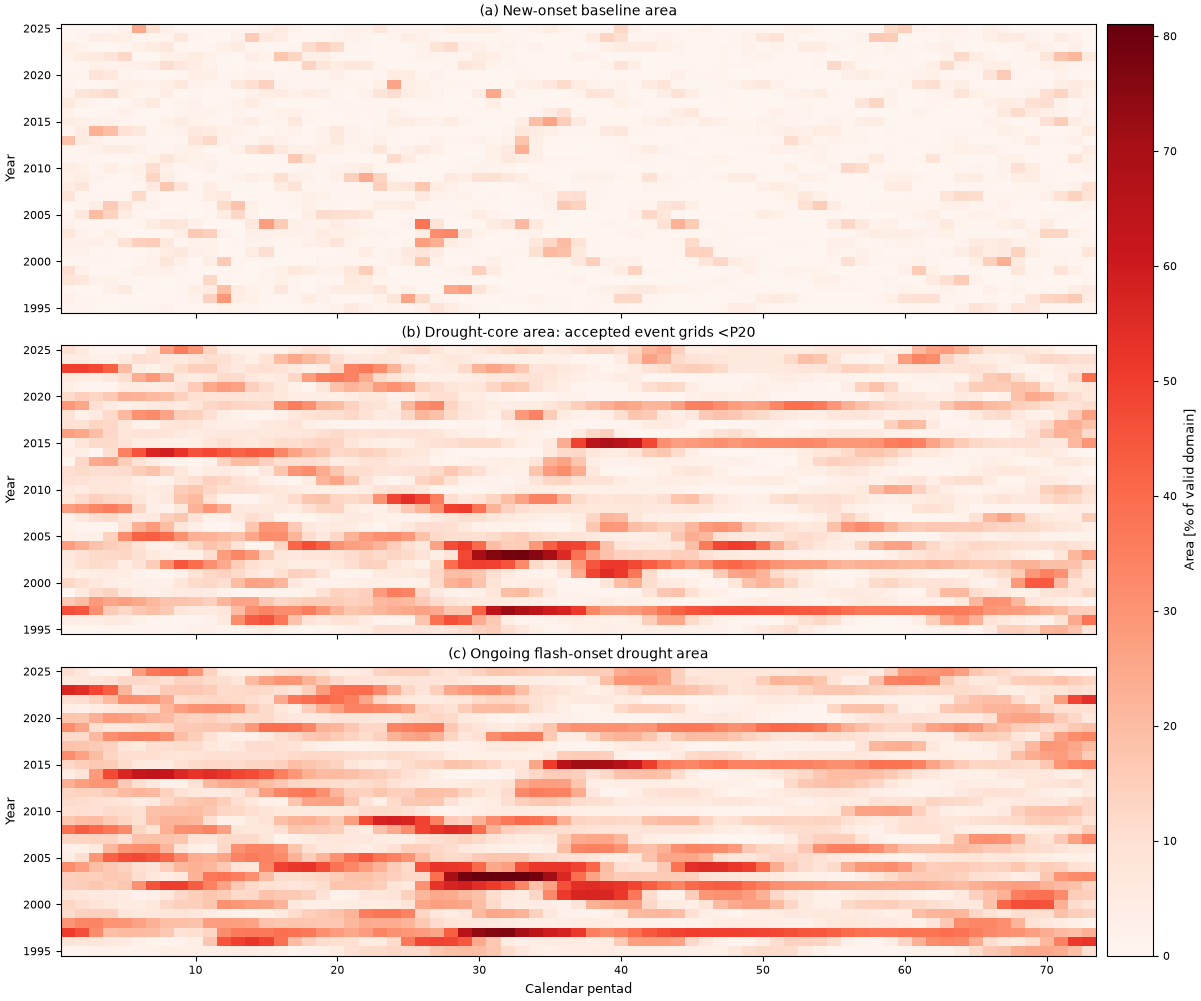

In [18]:
heatmap_columns = [
    (
        "new_onset_area_percent",
        "(a) New-onset baseline area",
    ),
    (
        "drought_core_area_percent",
        "(b) Drought-core area: accepted event grids <P20",
    ),
    (
        "active_event_area_percent",
        "(c) Ongoing flash-onset drought area",
    ),
]

heatmaps = []
for column, title in heatmap_columns:
    table = (
        pentad_screening
        .pivot(index="year", columns="pentad", values=column)
        .sort_index()
    )
    heatmaps.append((table, title))

shared_vmax = max(
    float(np.nanmax(table.values))
    for table, _ in heatmaps
)
shared_vmax = max(shared_vmax, 1.0e-6)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(12, 10),
    sharex=True,
    constrained_layout=True,
)

for ax, (table, title) in zip(axes, heatmaps):
    image = ax.imshow(
        table.values,
        aspect="auto",
        origin="lower",
        extent=[
            0.5,
            73.5,
            table.index.min() - 0.5,
            table.index.max() + 0.5,
        ],
        cmap="Reds",
        vmin=0,
        vmax=shared_vmax,
        interpolation="nearest",
    )
    ax.set(title=title, ylabel="Year")

axes[-1].set_xlabel("Calendar pentad")
fig.colorbar(
    image,
    ax=axes.tolist(),
    pad=0.01,
    label="Area [% of valid domain]",
)

save_figure(fig, f"figure_heatmaps_{domain_tag}")
plt.show()


## 18. Pilih tahun, pentad, dan grid contoh

Pemilihan otomatis menggunakan:

- tahun teratas menurut `YEAR_SELECTION_METRIC`;
- pentad maksimum menurut `PEAK_SELECTION_METRIC`;
- grid valid terdekat dengan centroid berbobot dari cluster terbesar pada pentad tersebut.

Dengan demikian, grid tidak lagi dipilih karena memiliki percentile paling rendah.


In [19]:
selected_year = (
    int(annual_ranking.iloc[0]["year"])
    if SELECTED_YEAR is None
    else int(SELECTED_YEAR)
)

selected_year_table = (
    pentad_screening[
        pentad_screening["year"] == selected_year
    ]
    .copy()
    .sort_values("pentad")
)

if selected_year_table.empty:
    raise ValueError(f"Tahun {selected_year} tidak tersedia.")

if PEAK_SELECTION_METRIC not in selected_year_table.columns:
    raise KeyError(
        f"PEAK_SELECTION_METRIC='{PEAK_SELECTION_METRIC}' tidak tersedia. "
        f"Kolom: {list(selected_year_table.columns)}"
    )

peak_row = selected_year_table.loc[
    selected_year_table[PEAK_SELECTION_METRIC].idxmax()
]
peak_index = int(peak_row["time_index"])
peak_pentad = int(peak_row["pentad"])

if SELECTED_LAT is not None and SELECTED_LON is not None:
    selected_lat = float(SELECTED_LAT)
    selected_lon = float(SELECTED_LON)
    selection_method = "manual coordinate"

    nearest_valid = valid_grid.sel(
        latitude=selected_lat,
        longitude=selected_lon,
        method="nearest",
    )
    if not bool(nearest_valid.item()):
        raise ValueError(
            "Koordinat manual terdekat berada di luar valid_grid."
        )

else:
    if "core" in PEAK_SELECTION_METRIC:
        cluster_source = (
            core_mask.isel(time_index=peak_index)
            .compute()
            .values
            .astype(bool)
        )
        cluster_name = "drought-core"
    else:
        cluster_source = (
            active_mask.isel(time_index=peak_index)
            .compute()
            .values
            .astype(bool)
        )
        cluster_name = "active-event"

    if not cluster_source.any():
        cluster_source = (
            active_mask.isel(time_index=peak_index)
            .compute()
            .values
            .astype(bool)
        )
        cluster_name = "active-event fallback"

    labels, nlabels = ndimage.label(
        cluster_source,
        structure=np.ones((3, 3), dtype=np.int8),
    )

    if nlabels == 0:
        raise ValueError(
            "Tidak ada cluster pada pentad yang dipilih."
        )

    weight_values = area_weight.fillna(0).values
    cluster_weights = np.bincount(
        labels.ravel(),
        weights=np.where(
            cluster_source,
            weight_values,
            0.0,
        ).ravel(),
    )
    largest_label = int(
        np.argmax(cluster_weights[1:]) + 1
    )
    largest_cluster_mask = labels == largest_label

    row_indices, column_indices = np.where(
        largest_cluster_mask
    )
    point_weights = weight_values[
        row_indices,
        column_indices,
    ]

    latitude_values = ds_fd["latitude"].values
    longitude_values = ds_fd["longitude"].values

    centroid_lat = float(
        np.average(
            latitude_values[row_indices],
            weights=point_weights,
        )
    )
    centroid_lon = float(
        np.average(
            longitude_values[column_indices],
            weights=point_weights,
        )
    )

    dy = latitude_values[row_indices] - centroid_lat
    dx = (
        longitude_values[column_indices] - centroid_lon
    ) * np.cos(np.deg2rad(centroid_lat))
    nearest_position = int(np.argmin(dx * dx + dy * dy))

    lat_index = int(row_indices[nearest_position])
    lon_index = int(column_indices[nearest_position])

    selected_lat = float(latitude_values[lat_index])
    selected_lon = float(longitude_values[lon_index])
    selection_method = (
        f"nearest valid grid to the weighted centroid of "
        f"the largest {cluster_name} cluster"
    )

print("Tahun kandidat:", selected_year)
print("Metrik pemilihan tahun:", YEAR_SELECTION_METRIC)
print("Pentad puncak:", peak_pentad)
print("Metrik pemilihan pentad:", PEAK_SELECTION_METRIC)
print("Grid contoh:", f"({selected_lat:.2f}, {selected_lon:.2f})")
print("Metode grid:", selection_method)
print(
    "Nilai metrik puncak:",
    round(float(peak_row[PEAK_SELECTION_METRIC]), 3),
    "%",
)


Tahun kandidat: 2003
Metrik pemilihan tahun: maximum_drought_core_area_percent
Pentad puncak: 33
Metrik pemilihan pentad: drought_core_area_percent
Grid contoh: (0.20, 113.70)
Metode grid: nearest valid grid to the weighted centroid of the largest drought-core cluster
Nilai metrik puncak: 79.129 %


## 19. Identifikasi kejadian pada grid contoh


In [20]:
point_pct = pct_time.sel(
    latitude=selected_lat,
    longitude=selected_lon,
    method="nearest",
).compute()

point_rzsm = rzsm_time.sel(
    latitude=selected_lat,
    longitude=selected_lon,
    method="nearest",
).compute()

point = ds_fd.sel(
    latitude=selected_lat,
    longitude=selected_lon,
    method="nearest",
).compute()

selected_event_id = int(
    point["fd_event_id"].isel(time_index=peak_index).item()
)

if selected_event_id > 0:
    event_positions = np.flatnonzero(
        point["fd_event_id"].values == selected_event_id
    )
    baseline_candidates = event_positions[
        point["fd_event_start"].values[event_positions] == 1
    ]
    if len(baseline_candidates) != 1:
        raise AssertionError(
            "Event aktif tidak memiliki tepat satu baseline."
        )
    baseline_index = int(baseline_candidates[0])

else:
    year_indices = np.flatnonzero(
        year_of_step == selected_year
    )
    baseline_candidates = year_indices[
        point["fd_event_start"].values[year_indices] == 1
    ]

    if len(baseline_candidates) == 0:
        raise ValueError(
            "Grid contoh tidak memiliki event pada tahun kandidat."
        )

    baseline_index = int(
        baseline_candidates[
            np.argmin(
                np.abs(
                    baseline_candidates - peak_index
                )
            )
        ]
    )
    selected_event_id = int(
        point["fd_event_id"].values[baseline_index]
    )

crossing_index = int(
    point["crossing_index_at_start"].values[baseline_index]
)
minimum_index = int(
    point["minimum_index_at_start"].values[baseline_index]
)
termination_index = int(
    point["termination_index_at_start"].values[baseline_index]
)

if not (
    baseline_index
    < crossing_index
    <= minimum_index
    < termination_index
    < ntime
):
    raise AssertionError(
        "Urutan baseline-crossing-minimum-termination tidak valid: "
        f"{baseline_index}, {crossing_index}, "
        f"{minimum_index}, {termination_index}"
    )

duration_pentads = int(
    point["duration_pentads_at_start"].values[baseline_index]
)
onset_time_pentads = int(
    point["onset_time_pentads_at_start"].values[baseline_index]
)
below_p20_pentads = int(
    point["below_p20_pentads_at_start"].values[baseline_index]
)
recovery_time_pentads = int(
    point["recovery_time_pentads_at_start"].values[baseline_index]
)
onset_speed_value = float(
    point["onset_speed_at_start"].values[baseline_index]
)
severity40_value = float(
    point["severity_p40_at_start"].values[baseline_index]
)
severity20_value = float(
    point["severity_p20_at_start"].values[baseline_index]
)
event_class_code = int(
    point["event_class_at_start"].values[baseline_index]
)
event_class_label = (
    "flash-onset prolonged drought"
    if event_class_code == 2
    else "flash drought"
)

print("Event ID:", selected_event_id)
print("Event class:", event_class_label)
print(
    "Baseline:",
    int(year_of_step[baseline_index]),
    int(pentad_of_step[baseline_index]),
)
print(
    "Crossing <P20:",
    int(year_of_step[crossing_index]),
    int(pentad_of_step[crossing_index]),
)
print(
    "Minimum:",
    int(year_of_step[minimum_index]),
    int(pentad_of_step[minimum_index]),
)
print(
    "Termination >=P20:",
    int(year_of_step[termination_index]),
    int(pentad_of_step[termination_index]),
)
print("Onset speed:", round(onset_speed_value, 2), "pp/pentad")
print("Duration:", duration_pentads, "pentads")


Event ID: 21
Event class: flash drought
Baseline: 2003 27
Crossing <P20: 2003 28
Minimum: 2003 30
Termination >=P20: 2003 38
Onset speed: 25.71 pp/pentad
Duration: 11 pentads


## 20. Plot satu grid: percentile, RZSM aktual, fase, dan severity


Figur tersimpan: D:\ERA5_LAND\output_fd_q1_revisi_final\figure_selected_grid_event_bbox_screening


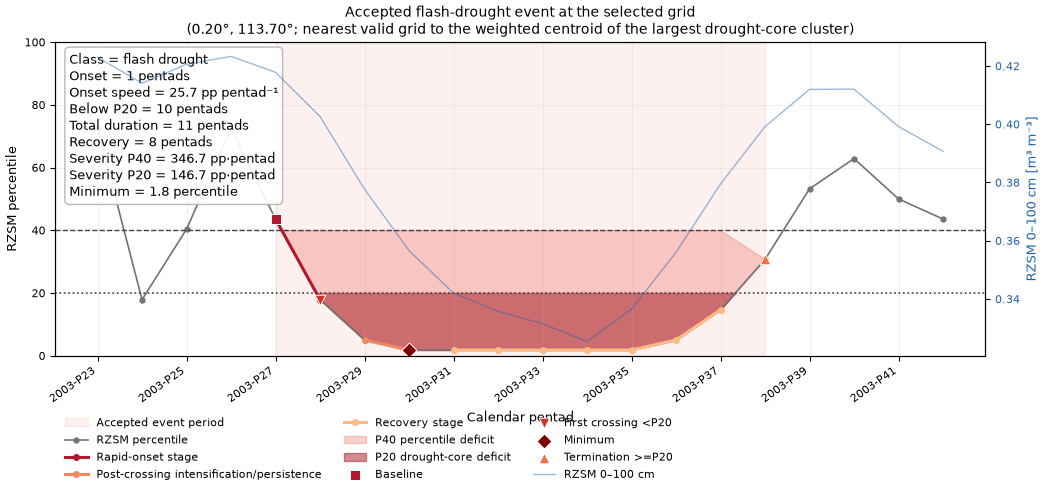

In [21]:
left_index = max(0, baseline_index - 4)
right_index = min(
    ntime - 1,
    termination_index + 4,
)
plot_indices = np.arange(
    left_index,
    right_index + 1,
)
x = np.arange(len(plot_indices))

p = point_pct.values[plot_indices]
rzsm_values = point_rzsm.values[plot_indices]
phase_values = point["fd_phase"].values[plot_indices]

baseline_x = baseline_index - left_index
crossing_x = crossing_index - left_index
minimum_x = minimum_index - left_index
termination_x = termination_index - left_index

event_in_window = (
    (plot_indices >= baseline_index)
    & (plot_indices < termination_index)
)
core_in_window = (
    event_in_window
    & (p < DROUGHT_THRESHOLD)
)

fig, ax = plt.subplots(figsize=(12, 5.6))
ax_rzsm = ax.twinx()

ax.axvspan(
    baseline_x,
    termination_x,
    color="#ef3b2c",
    alpha=0.07,
    label="Accepted event period",
)

ax.plot(
    x,
    p,
    color="0.45",
    marker="o",
    markersize=3.5,
    linewidth=1.2,
    label="RZSM percentile",
)

for phase_code, label, color in [
    (1, "Rapid-onset stage", "#b2182b"),
    (2, "Post-crossing intensification/persistence", "#ef8a62"),
    (3, "Recovery stage", "#fdbb84"),
]:
    mask = phase_values == phase_code
    if mask.any():
        ax.plot(
            x[mask],
            p[mask],
            color=color,
            marker="o",
            markersize=4,
            linewidth=2.2,
            label=label,
        )

ax.fill_between(
    x,
    p,
    START_THRESHOLD,
    where=event_in_window & (p < START_THRESHOLD),
    interpolate=True,
    color="#ef3b2c",
    alpha=0.24,
    label="P40 percentile deficit",
)
ax.fill_between(
    x,
    p,
    DROUGHT_THRESHOLD,
    where=core_in_window,
    interpolate=True,
    color="#99000d",
    alpha=0.45,
    label="P20 drought-core deficit",
)

ax.axhline(
    START_THRESHOLD,
    color="0.25",
    linestyle="--",
    linewidth=1,
)
ax.axhline(
    DROUGHT_THRESHOLD,
    color="0.25",
    linestyle=":",
    linewidth=1.2,
)

markers = [
    (
        baseline_x,
        p[baseline_x],
        "s",
        "#b2182b",
        "Baseline",
    ),
    (
        crossing_x,
        p[crossing_x],
        "v",
        "#d73027",
        "First crossing <P20",
    ),
    (
        minimum_x,
        p[minimum_x],
        "D",
        "#7f0000",
        "Minimum",
    ),
    (
        termination_x,
        p[termination_x],
        "^",
        "#f46d43",
        "Termination >=P20",
    ),
]

for xpos, ypos, marker, color, label in markers:
    ax.scatter(
        xpos,
        ypos,
        marker=marker,
        s=58,
        color=color,
        edgecolor="white",
        linewidth=0.7,
        zorder=8,
        label=label,
    )

ax_rzsm.plot(
    x,
    rzsm_values,
    color="#2166ac",
    linewidth=1.0,
    alpha=0.45,
    label="RZSM 0–100 cm",
)
ax_rzsm.set_ylabel(
    "RZSM 0–100 cm [m³ m⁻³]",
    color="#2166ac",
)
ax_rzsm.tick_params(
    axis="y",
    labelcolor="#2166ac",
)

annotation = (
    f"Class = {event_class_label}\n"
    f"Onset = {onset_time_pentads} pentads\n"
    f"Onset speed = {onset_speed_value:.1f} pp pentad⁻¹\n"
    f"Below P20 = {below_p20_pentads} pentads\n"
    f"Total duration = {duration_pentads} pentads\n"
    f"Recovery = {recovery_time_pentads} pentads\n"
    f"Severity P40 = {severity40_value:.1f} pp·pentad\n"
    f"Severity P20 = {severity20_value:.1f} pp·pentad\n"
    f"Minimum = {point_pct.values[minimum_index]:.1f} percentile"
)

ax.text(
    0.015,
    0.97,
    annotation,
    transform=ax.transAxes,
    va="top",
    ha="left",
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "white",
        "edgecolor": "0.7",
        "alpha": 0.92,
    },
)

year_plot = year_of_step[plot_indices]
pentad_plot = pentad_of_step[plot_indices]
tick_step = max(1, len(x) // 8)
tick_positions = x[::tick_step]
tick_labels = [
    f"{int(year_plot[position])}-P{int(pentad_plot[position]):02d}"
    for position in tick_positions
]

ax.set_xticks(
    tick_positions,
    tick_labels,
    rotation=35,
    ha="right",
)
ax.set(
    ylabel="RZSM percentile",
    xlabel="Calendar pentad",
    ylim=(0, 100),
    title=(
        "Accepted flash-drought event at the selected grid\n"
        f"({selected_lat:.2f}°, {selected_lon:.2f}°; "
        f"{selection_method})"
    ),
)
ax.grid(alpha=0.18)

handles_1, labels_1 = ax.get_legend_handles_labels()
handles_2, labels_2 = ax_rzsm.get_legend_handles_labels()
unique = dict(
    zip(
        labels_1 + labels_2,
        handles_1 + handles_2,
    )
)
ax.legend(
    unique.values(),
    unique.keys(),
    frameon=False,
    loc="lower left",
    bbox_to_anchor=(0, -0.43),
    ncol=3,
)
fig.subplots_adjust(bottom=0.32)

save_figure(
    fig,
    f"figure_selected_grid_event_{domain_tag}",
)
plt.show()


## 21. Evolusi metrik area pada tahun kandidat


Figur tersimpan: D:\ERA5_LAND\output_fd_q1_revisi_final\figure_selected_year_area_bbox_screening


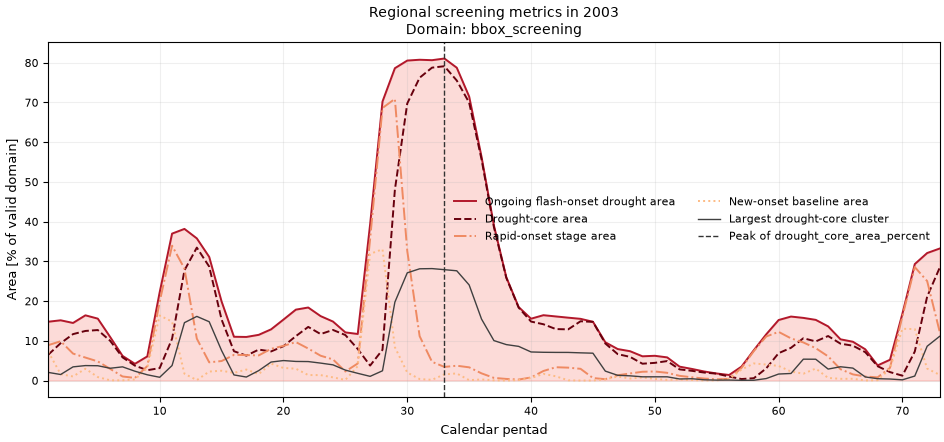

In [22]:
selected_area = (
    pentad_screening[
        pentad_screening["year"] == selected_year
    ]
    .sort_values("pentad")
)

pentads = selected_area["pentad"].to_numpy()
active_values = selected_area[
    "active_event_area_percent"
].to_numpy()
core_values = selected_area[
    "drought_core_area_percent"
].to_numpy()
rapid_values = selected_area[
    "rapid_onset_stage_area_percent"
].to_numpy()
new_values = selected_area[
    "new_onset_area_percent"
].to_numpy()

fig, ax = plt.subplots(figsize=(11.5, 4.6))

ax.plot(
    pentads,
    active_values,
    color="#b2182b",
    label="Ongoing flash-onset drought area",
)
ax.fill_between(
    pentads,
    0,
    active_values,
    color="#ef3b2c",
    alpha=0.18,
)
ax.plot(
    pentads,
    core_values,
    color="#67000d",
    linestyle="--",
    label="Drought-core area",
)
ax.plot(
    pentads,
    rapid_values,
    color="#ef8a62",
    linestyle="-.",
    label="Rapid-onset stage area",
)
ax.plot(
    pentads,
    new_values,
    color="#fdbb84",
    linestyle=":",
    label="New-onset baseline area",
)

if CALCULATE_LARGEST_CLUSTER:
    ax.plot(
        pentads,
        selected_area[
            "largest_core_cluster_percent"
        ].to_numpy(),
        color="0.25",
        linewidth=1.0,
        label="Largest drought-core cluster",
    )

ax.axvline(
    peak_pentad,
    color="0.2",
    linestyle="--",
    linewidth=1,
    label=f"Peak of {PEAK_SELECTION_METRIC}",
)

ax.set(
    xlabel="Calendar pentad",
    ylabel="Area [% of valid domain]",
    title=(
        f"Regional screening metrics in {selected_year}\n"
        f"Domain: {domain_tag}"
    ),
    xlim=(1, 73),
)
ax.grid(alpha=0.2)
ax.legend(frameon=False, ncol=2)

save_figure(
    fig,
    f"figure_selected_year_area_{domain_tag}",
)
plt.show()


## 22. Snapshot spasial nasional

Panel-panel berikut adalah **snapshot seluruh grid yang sedang aktif**, bukan pelacakan
satu objek regional yang sama. Bintang menunjukkan grid contoh.


Figur tersimpan: D:\ERA5_LAND\output_fd_q1_revisi_final\figure_national_active_grid_snapshots_bbox_screening


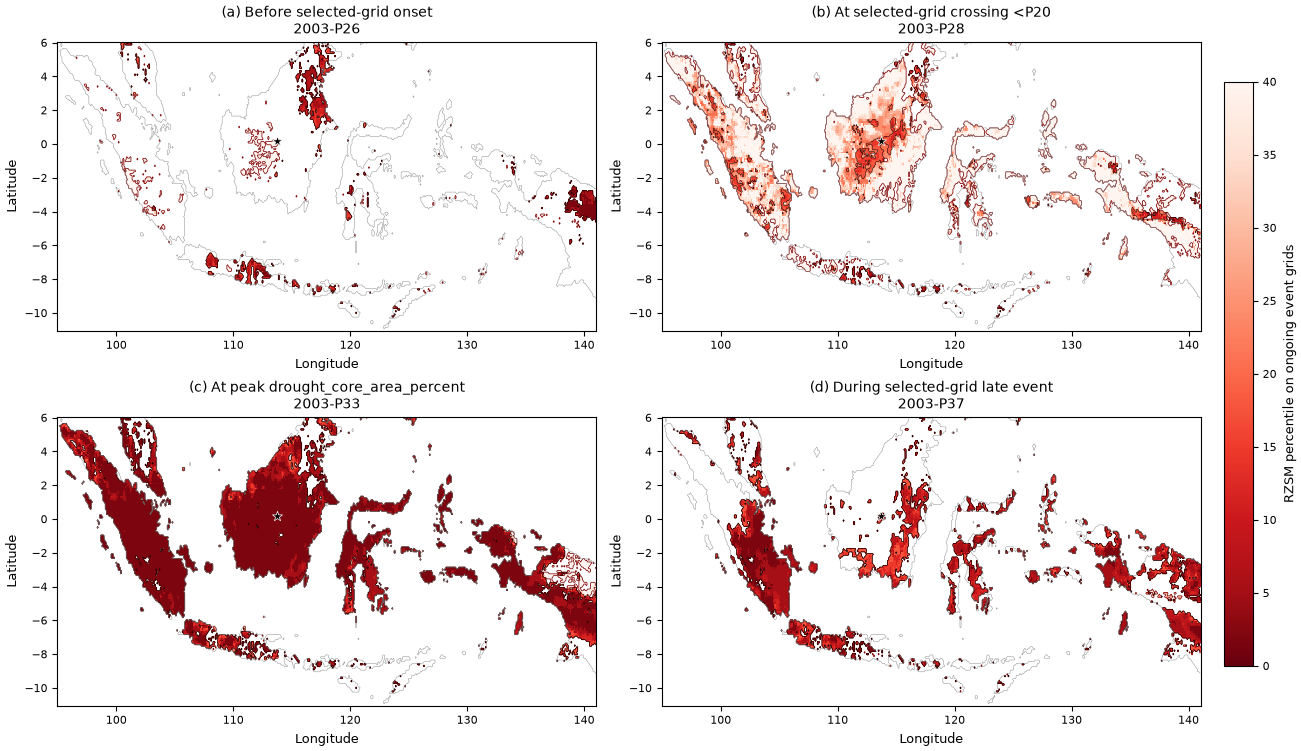

In [23]:
before_onset_index = max(
    0,
    baseline_index - 1,
)
late_event_index = min(
    termination_index - 1,
    ntime - 1,
)

map_indices = [
    before_onset_index,
    crossing_index,
    peak_index,
    late_event_index,
]
map_titles = [
    "Before selected-grid onset",
    "At selected-grid crossing <P20",
    f"At peak {PEAK_SELECTION_METRIC}",
    "During selected-grid late event",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 7.5),
    constrained_layout=True,
)

mesh = None

for panel, (
    ax,
    map_index,
    stage_title,
) in enumerate(
    zip(
        axes.ravel(),
        map_indices,
        map_titles,
    )
):
    percentile_map = (
        pct_time.isel(time_index=map_index)
        .transpose("latitude", "longitude")
        .where(valid_grid)
        .compute()
    )
    active_map = (
        active_mask.isel(time_index=map_index)
        .transpose("latitude", "longitude")
        .compute()
    )
    core_map = (
        core_mask.isel(time_index=map_index)
        .transpose("latitude", "longitude")
        .compute()
    )

    displayed = percentile_map.where(active_map)

    mesh = ax.pcolormesh(
        displayed["longitude"],
        displayed["latitude"],
        displayed,
        cmap="Reds_r",
        vmin=0,
        vmax=40,
        shading="auto",
    )

    if bool(active_map.any()):
        ax.contour(
            active_map["longitude"],
            active_map["latitude"],
            active_map.astype(int),
            levels=[0.5],
            colors="#7f0000",
            linewidths=0.55,
        )

    if bool(core_map.any()):
        ax.contour(
            core_map["longitude"],
            core_map["latitude"],
            core_map.astype(int),
            levels=[0.5],
            colors="black",
            linewidths=0.35,
        )

    ax.contour(
        valid_grid["longitude"],
        valid_grid["latitude"],
        valid_grid.astype(int),
        levels=[0.5],
        colors="0.55",
        linewidths=0.35,
    )

    ax.scatter(
        selected_lon,
        selected_lat,
        marker="*",
        s=58,
        color="black",
        edgecolor="white",
        linewidth=0.5,
        zorder=5,
    )

    ax.set(
        title=(
            f"({chr(97 + panel)}) {stage_title}\n"
            f"{int(year_of_step[map_index])}-"
            f"P{int(pentad_of_step[map_index]):02d}"
        ),
        xlabel="Longitude",
        ylabel="Latitude",
    )

fig.colorbar(
    mesh,
    ax=axes.ravel().tolist(),
    pad=0.02,
    shrink=0.88,
    label="RZSM percentile on ongoing event grids",
)

save_figure(
    fig,
    f"figure_national_active_grid_snapshots_{domain_tag}",
)
plt.show()


## 23. Figur multi-panel ringkas


Figur tersimpan: D:\ERA5_LAND\output_fd_q1_revisi_final\figure_main_flash_drought_framework_bbox_screening


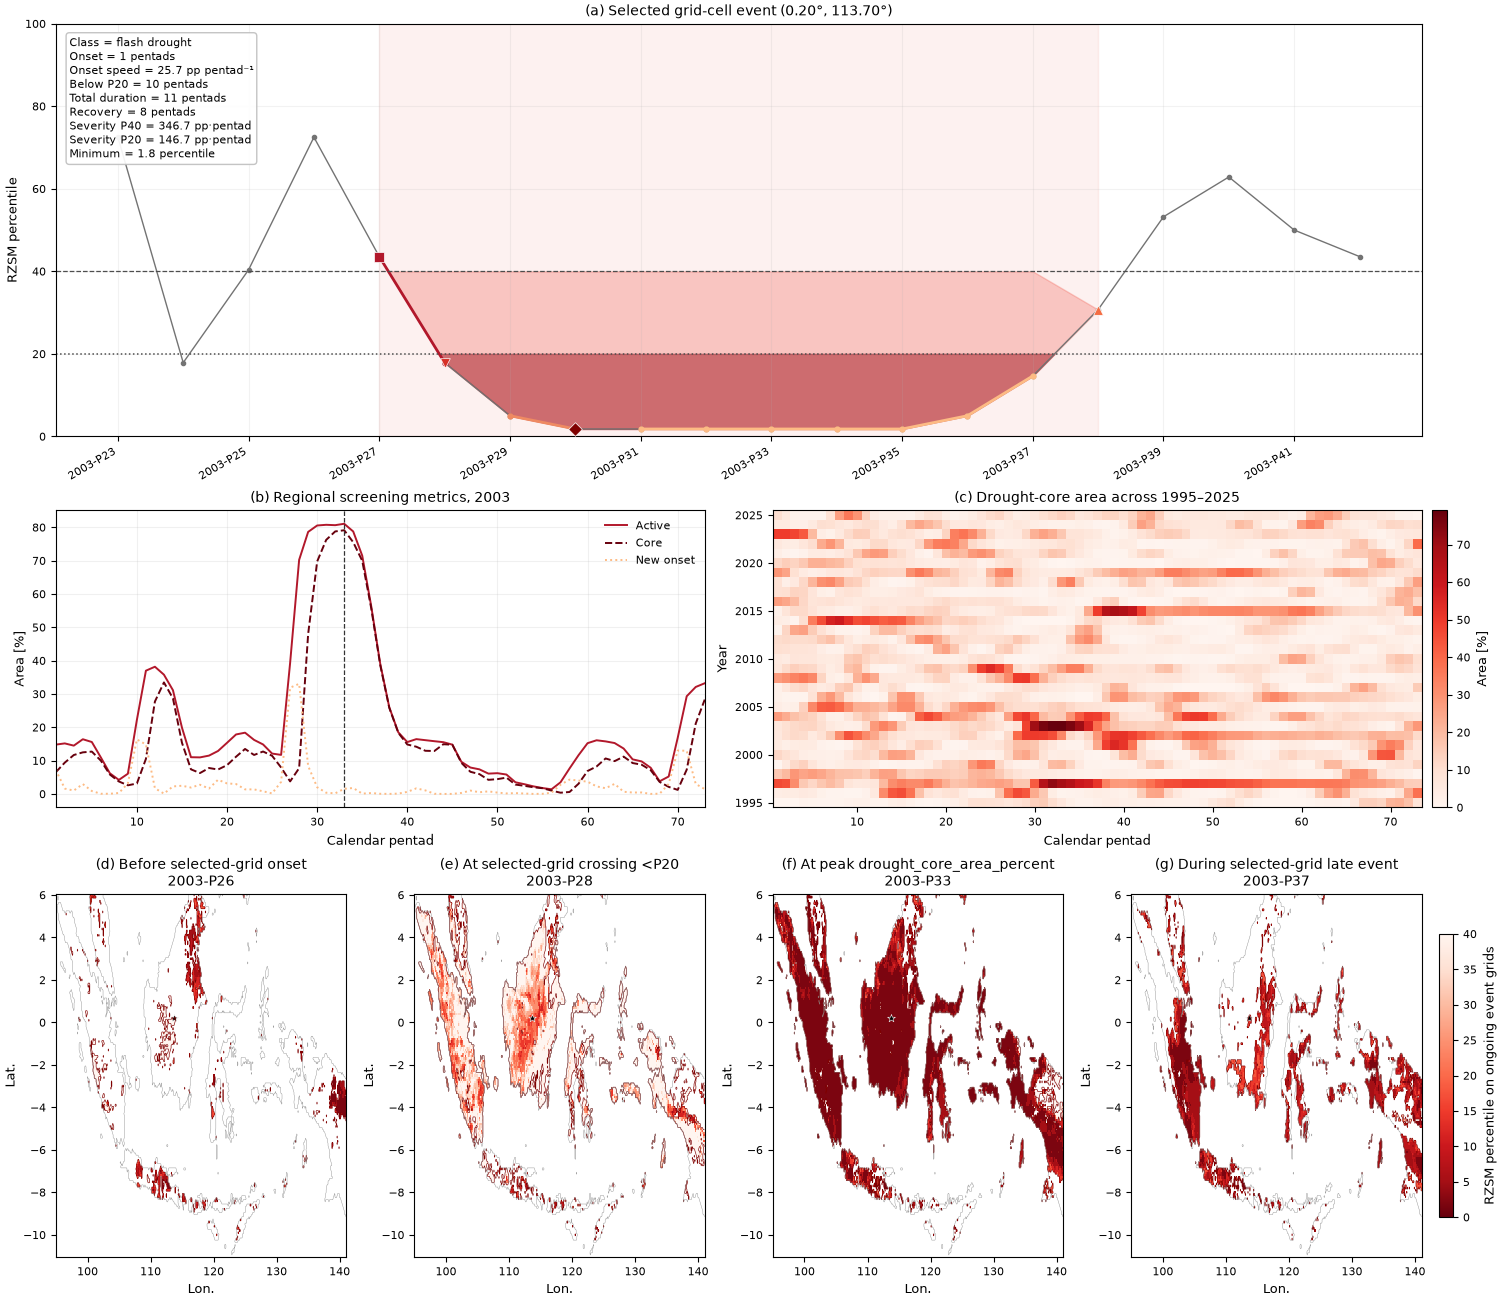

In [24]:
heatmap_core = (
    pentad_screening
    .pivot(
        index="year",
        columns="pentad",
        values="drought_core_area_percent",
    )
    .sort_index()
)

fig = plt.figure(
    figsize=(15, 13),
    constrained_layout=True,
)
grid_spec = fig.add_gridspec(
    3,
    4,
    height_ratios=[1.25, 0.9, 1.1],
)

# Panel a: event pada grid contoh.
ax_a = fig.add_subplot(grid_spec[0, :])
ax_a.axvspan(
    baseline_x,
    termination_x,
    color="#ef3b2c",
    alpha=0.07,
)
ax_a.plot(
    x,
    p,
    color="0.45",
    marker="o",
    markersize=3,
    linewidth=1,
)
for phase_code, color in [
    (1, "#b2182b"),
    (2, "#ef8a62"),
    (3, "#fdbb84"),
]:
    mask = phase_values == phase_code
    if mask.any():
        ax_a.plot(
            x[mask],
            p[mask],
            color=color,
            marker="o",
            markersize=3.5,
            linewidth=2,
        )

ax_a.fill_between(
    x,
    p,
    START_THRESHOLD,
    where=event_in_window & (p < START_THRESHOLD),
    interpolate=True,
    color="#ef3b2c",
    alpha=0.24,
)
ax_a.fill_between(
    x,
    p,
    DROUGHT_THRESHOLD,
    where=core_in_window,
    interpolate=True,
    color="#99000d",
    alpha=0.45,
)
ax_a.axhline(
    START_THRESHOLD,
    color="0.3",
    linestyle="--",
    linewidth=0.9,
)
ax_a.axhline(
    DROUGHT_THRESHOLD,
    color="0.3",
    linestyle=":",
    linewidth=1.1,
)
for xpos, ypos, marker, color, label in markers:
    ax_a.scatter(
        xpos,
        ypos,
        marker=marker,
        s=48,
        color=color,
        edgecolor="white",
        linewidth=0.5,
        zorder=8,
    )
ax_a.set_xticks(
    tick_positions,
    tick_labels,
    rotation=30,
    ha="right",
)
ax_a.set(
    ylim=(0, 100),
    ylabel="RZSM percentile",
    title=(
        "(a) Selected grid-cell event "
        f"({selected_lat:.2f}°, {selected_lon:.2f}°)"
    ),
)
ax_a.grid(alpha=0.16)
ax_a.text(
    0.01,
    0.97,
    annotation,
    transform=ax_a.transAxes,
    va="top",
    fontsize=8,
    bbox={
        "boxstyle": "round,pad=0.3",
        "facecolor": "white",
        "edgecolor": "0.75",
        "alpha": 0.92,
    },
)

# Panel b: area metrics.
ax_b = fig.add_subplot(grid_spec[1, :2])
ax_b.plot(
    pentads,
    active_values,
    color="#b2182b",
    label="Active",
)
ax_b.plot(
    pentads,
    core_values,
    color="#67000d",
    linestyle="--",
    label="Core",
)
ax_b.plot(
    pentads,
    new_values,
    color="#fdbb84",
    linestyle=":",
    label="New onset",
)
ax_b.axvline(
    peak_pentad,
    color="0.2",
    linestyle="--",
    linewidth=0.9,
)
ax_b.set(
    title=f"(b) Regional screening metrics, {selected_year}",
    xlabel="Calendar pentad",
    ylabel="Area [%]",
    xlim=(1, 73),
)
ax_b.grid(alpha=0.18)
ax_b.legend(frameon=False)

# Panel c: drought-core heatmap.
ax_c = fig.add_subplot(grid_spec[1, 2:])
image_c = ax_c.imshow(
    heatmap_core.values,
    aspect="auto",
    origin="lower",
    extent=[
        0.5,
        73.5,
        heatmap_core.index.min() - 0.5,
        heatmap_core.index.max() + 0.5,
    ],
    cmap="Reds",
    interpolation="nearest",
)
ax_c.set(
    title="(c) Drought-core area across 1995–2025",
    xlabel="Calendar pentad",
    ylabel="Year",
)
fig.colorbar(
    image_c,
    ax=ax_c,
    pad=0.01,
    label="Area [%]",
)

# Panel d–g: national snapshots.
map_axes = []
mesh = None

for index, (
    map_index,
    stage_title,
) in enumerate(
    zip(map_indices, map_titles)
):
    ax = fig.add_subplot(grid_spec[2, index])
    map_axes.append(ax)

    percentile_map = (
        pct_time.isel(time_index=map_index)
        .transpose("latitude", "longitude")
        .where(valid_grid)
        .compute()
    )
    active_map = (
        active_mask.isel(time_index=map_index)
        .transpose("latitude", "longitude")
        .compute()
    )
    displayed = percentile_map.where(active_map)

    mesh = ax.pcolormesh(
        displayed["longitude"],
        displayed["latitude"],
        displayed,
        cmap="Reds_r",
        vmin=0,
        vmax=40,
        shading="auto",
    )

    if bool(active_map.any()):
        ax.contour(
            active_map["longitude"],
            active_map["latitude"],
            active_map.astype(int),
            levels=[0.5],
            colors="#7f0000",
            linewidths=0.45,
        )

    ax.contour(
        valid_grid["longitude"],
        valid_grid["latitude"],
        valid_grid.astype(int),
        levels=[0.5],
        colors="0.55",
        linewidths=0.3,
    )

    ax.scatter(
        selected_lon,
        selected_lat,
        marker="*",
        s=35,
        color="black",
        edgecolor="white",
        linewidth=0.4,
    )
    ax.set(
        title=(
            f"({chr(100 + index)}) {stage_title}\n"
            f"{int(year_of_step[map_index])}-"
            f"P{int(pentad_of_step[map_index]):02d}"
        ),
        xlabel="Lon.",
        ylabel="Lat.",
    )

fig.colorbar(
    mesh,
    ax=map_axes,
    pad=0.01,
    shrink=0.78,
    label="RZSM percentile on ongoing event grids",
)

save_figure(
    fig,
    f"figure_main_flash_drought_framework_{domain_tag}",
)
plt.show()


## 24. Sensitivity analysis berikutnya

Jalankan sensitivity analysis pada notebook terpisah dengan mengubah satu komponen
pada satu waktu.

| Komponen | Primer | Alternatif |
|---|---:|---:|
| start threshold | P40 | P35, P45 |
| drought threshold | P20 | P15, P25 |
| onset speed | 5 pp/pentad | 4, 6 |
| maximum onset | tidak dibatasi | 4, 5 pentad |
| minimum di bawah P20 | 1 pentad | 2, 3 pentad |
| minimum total duration | 4 interval | 3, 5 |
| maximum total duration | tidak dibatasi | 12, 18 pentad |
| monotonic onset | True | False |

Bandingkan jumlah grid-cell events, distribusi onset, persentase prolonged events,
tahun kandidat, maksimum drought-core area, dan overlap spasial.

## Interpretasi wajib

- `grid-cell event` bukan satu kejadian regional independen;
- `active_event_area_percent` mencakup fase onset, persistence, dan recovery;
- peta snapshot tidak melacak satu objek spasial yang sama;
- bila `domain_tag == "bbox_screening"`, hasil belum boleh disebut statistik Indonesia final;
- dampak pertanian tidak boleh disimpulkan hanya dari RZSM.

## Keluaran utama

Nama file memiliki akhiran `indonesia` bila polygon berhasil diterapkan, atau
`bbox_screening` bila hanya bounding box yang digunakan.

- `fd_detection_primary_1995_2025_<domain>.nc`
- `fd_gridcell_event_catalog_1995_2025_<domain>.csv`
- `fd_pentad_area_screening_1995_2025_<domain>.csv`
- `fd_annual_regional_screening_1995_2025_<domain>.csv`
- `fd_run_manifest_1995_2025_<domain>.json`
